# 불량 탐지 및 SHAP 기반 공정 전이 위험 예측

1. 라이브러리 import 및 Colab/Google Drive 로드
2. `app/ml/datasets/process/` 전체 데이터셋 정제 및 전처리
3. Bosch, Ford, 열화상, 소성가공 데이터 기반 보조 모델/피처 학습
4. 후보 모델 4종(LightGBM, RandomForest, ExtraTrees, LogisticRegression) 교차검증/튜닝
5. 최종 후보별 성능 비교, Accuracy, False Positive Rate, Confusion Matrix
6. SHAP 기반 영향 공정 분석 및 공정 간 전이 위험 결과 생성
7. AI 모델 관리 항목과 모델/결과 파일 저장

> 현재 데이터에는 `BODY 불량 -> PAINT 불량` 같은 실제 전이 정답 라벨과 데이터셋 간 공통 제품 키가 없습니다. 따라서 이 노트북의 전이 예측은 별도 전이 라벨 학습이 아니라, `최종 불량 확률 + SHAP 영향 공정 + 보조 공정 위험 피처 + 공정 흐름 규칙` 기반 위험 확산 해석입니다.


In [1]:
# Colab 환경에서 필요한 패키지 설치
import importlib.util
import subprocess
import sys

def ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])

ensure_package("lightgbm")
ensure_package("shap")
ensure_package("joblib")
ensure_package("optuna")
ensure_package("imblearn", "imbalanced-learn")


In [2]:
# CPU 병렬 사용
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
)

> 필요한 추가 패키지(`optuna`, `imbalanced-learn`)는 위 설치 셀에서 자동 확인/설치합니다.


In [3]:
from __future__ import annotations

import gc
import json
import pickle
import re
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from optuna.samplers import TPESampler
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas", pd.__version__)
print("lightgbm", lgb.__version__)
print("optuna", optuna.__version__)
print("shap", shap.__version__)


pandas 2.2.2
lightgbm 4.6.0
optuna 4.9.0
shap 0.52.0


## 1. Google Drive 및 로컬 데이터셋 경로 설정


In [7]:
# Drive 마운트
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Colab이 아니므로 Google Drive mount를 건너뜁니다.")

# 데이터 루트
PROJECT_ROOT = Path("/content/drive/MyDrive") if IN_COLAB else Path.cwd()
PROCESS_ROOT = PROJECT_ROOT / "aims_dataset"
BOSCH_ROOT = PROCESS_ROOT / "bosch-production-line-performance"
THERMAL_ROOT = PROCESS_ROOT / "머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)"
FORD_ROOT = PROCESS_ROOT / "Ford 엔진 진동 데이터셋"
METAL_ROOT = PROCESS_ROOT / "소성가공 자원최적화 AI 데이터셋"
# 산출물 경로
OUTPUT_DIR = Path("/content/defect_transfer_outputs") if IN_COLAB else Path("outputs/defect_transfer")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bosch 파일 경로
NUMERIC_PATH = BOSCH_ROOT / "train_numeric.csv"
DATE_PATH = BOSCH_ROOT / "train_date.csv"
CATEGORICAL_PATH = BOSCH_ROOT / "train_categorical.csv"

# 열화상 파일 경로
THERMAL_LEFT_DATA_PATH = THERMAL_ROOT / "2nd_process_left_data.csv"
THERMAL_LEFT_LABEL_PATH = THERMAL_ROOT / "2nd_process_left_label.json"
THERMAL_RIGHT_DATA_PATH = THERMAL_ROOT / "2nd_process_right_data.csv"
THERMAL_RIGHT_LABEL_PATH = THERMAL_ROOT / "2nd_process_right_label.json"

# 보조 데이터 파일 경로
FORD_TRAIN_PATH = FORD_ROOT / "FordA_TRAIN.txt"
FORD_TEST_PATH = FORD_ROOT / "FordA_TEST.txt"
METAL_PROCESS_PATH = METAL_ROOT / "공정_데이터_2022년_8월.csv"
METAL_SENSOR_PATHS = sorted([p for p in METAL_ROOT.glob("*.csv") if p.name != "공정_데이터_2022년_8월.csv"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESS_ROOT:", PROCESS_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive
PROCESS_ROOT: /content/drive/MyDrive/aims_dataset
OUTPUT_DIR: /content/defect_transfer_outputs


## 2. 대용량 CSV 로드 전략

Bosch 데이터는 매우 크므로 전체 컬럼을 한 번에 읽지 않습니다. 먼저 일부 행만 프로파일링한 뒤 결측률이 낮고 변동이 있는 컬럼을 고르고, 선택 컬럼만 학습 크기만큼 로드합니다.


In [8]:
# 학습 규모 설정
PROFILE_ROWS = 50_000
MAX_ROWS = 300_000
MAX_NUMERIC_FEATURES = 260
MAX_DATE_FEATURES = 260
USE_CATEGORICAL = True
MAX_CATEGORICAL_FEATURES = 80
CATEGORICAL_PROFILE_ROWS = 20_000
MAX_AUX_ROWS = 200_000
ENABLE_HYPERPARAMETER_TUNING = True
CV_N_SPLITS = 5
# 불균형 데이터에서는 PR-AUC/Recall 안정성을 위해 충분한 탐색 횟수를 사용합니다.
# 실행 시간이 부담되면 CV_SAMPLE_SIZE 또는 CV_N_ITER를 낮춰 빠른 실험 모드로 전환합니다.
CV_N_ITER = 15
ENABLE_OPTUNA_TUNING = True
CV_SAMPLE_SIZE = 30_000
FINAL_TRAIN_SAMPLE_SIZE = 120_000
RETRAIN_SELECTED_MODEL_ON_FULL_DATA = False
USE_SMOTE = True
SMOTE_SAMPLING_STRATEGY = 0.10
RECALL_PRIORITY_TARGET = 0.35
RECALL_PRIORITY_MIN_PRECISION = 0.02
THRESHOLD_BETA = 2.0

# 공정 매핑
LINE_TO_PROCESS = {
    "L0": "PRESS",
    "L1": "BODY",
    "L2": "ASSEMBLY",
    "L3": "PAINT",
}
PROCESS_FLOW = ["PRESS", "BODY", "PAINT", "ASSEMBLY"]
PROCESS_DISPLAY = {
    "PRESS": "프레스",
    "BODY": "차체",
    "PAINT": "도장",
    "ASSEMBLY": "의장",
    "FINAL_INSPECTION": "최종검사",
    "UNKNOWN": "미분류",
}

# Colab Drive FUSE 연결이 불안정할 수 있어 데이터셋은 로컬 런타임 캐시에서 읽습니다.
LOCAL_DATA_CACHE = Path("/content/aims_dataset_cache") if IN_COLAB else None


def local_dataset_path(path: Path) -> Path:
    path = Path(path)
    if not IN_COLAB:
        return path
    if LOCAL_DATA_CACHE is None:
        return path

    try:
        relative_path = path.relative_to(PROJECT_ROOT)
    except ValueError:
        relative_path = Path(path.name)

    cached_path = LOCAL_DATA_CACHE / relative_path
    if cached_path.exists():
        try:
            if cached_path.stat().st_size == path.stat().st_size:
                return cached_path
        except OSError:
            # Drive stat 자체가 실패하면 이미 복사된 로컬 캐시를 우선 사용합니다.
            return cached_path

    cached_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        print(f"cache copy: {path} -> {cached_path}")
        shutil.copy2(path, cached_path)
    except OSError as exc:
        raise OSError(
            "Google Drive 연결이 끊겼습니다. Colab에서 drive.mount('/content/drive', force_remount=True)를 "
            "실행한 뒤 이 셀부터 다시 실행하세요."
        ) from exc
    return cached_path


def read_csv_stable(path: Path, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(local_dataset_path(path), **kwargs)
    except OSError as exc:
        if IN_COLAB and "Transport endpoint is not connected" in str(exc):
            raise OSError(
                "Google Drive 연결이 끊겼습니다. drive.mount('/content/drive', force_remount=True)로 "
                "재마운트한 뒤 다시 실행하세요. 이미 캐시된 파일은 /content/aims_dataset_cache에서 읽습니다."
            ) from exc
        raise


def read_json_stable(path: Path):
    with open(local_dataset_path(path), "r", encoding="utf-8") as f:
        return json.load(f)


# 파일 검증
def assert_file(path: Path):
    if not path.exists():
        cached_path = local_dataset_path(path) if IN_COLAB else path
        if not cached_path.exists():
            raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path}")

# 메모리 축소
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if col == "Id":
            df[col] = pd.to_numeric(df[col], downcast="integer")
            continue
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

# 라인 추출
def get_line(column: str) -> str:
    match = re.match(r"^(L\d+)_", column)
    return match.group(1) if match else "UNKNOWN"

# 스테이션 추출
def get_station(column: str) -> str:
    match = re.match(r"^(L\d+)_S(\d+)_", column)
    return f"{match.group(1)}_S{match.group(2)}" if match else "UNKNOWN"

# 컬럼 선별
def select_columns_by_profile(
    path: Path,
    *,
    required_cols: list[str],
    max_features: int,
    profile_rows: int,
    min_non_null_ratio: float = 0.02,
) -> list[str]:
    assert_file(path)
    sample = read_csv_stable(path, nrows=profile_rows)
    candidates = [c for c in sample.columns if c not in required_cols]
    non_null_ratio = sample[candidates].notna().mean()
    nunique = sample[candidates].nunique(dropna=True)
    score = (non_null_ratio * np.log1p(nunique)).sort_values(ascending=False)
    selected = score[(non_null_ratio >= min_non_null_ratio) & (nunique > 1)].head(max_features).index.tolist()
    del sample
    gc.collect()
    return required_cols + selected

# 선택 컬럼 로드
def read_selected_csv(path: Path, usecols: list[str], max_rows: int | None) -> pd.DataFrame:
    df = read_csv_stable(path, usecols=usecols, nrows=max_rows)
    return reduce_mem_usage(df)


In [9]:
# Bosch numeric 컬럼 선별
numeric_cols = select_columns_by_profile(
    NUMERIC_PATH,
    required_cols=["Id", "Response"],
    max_features=MAX_NUMERIC_FEATURES,
    profile_rows=PROFILE_ROWS,
)
# Bosch date 컬럼 선별
date_cols = select_columns_by_profile(
    DATE_PATH,
    required_cols=["Id"],
    max_features=MAX_DATE_FEATURES,
    profile_rows=PROFILE_ROWS,
)

# Bosch 선택 데이터 로드
numeric_df = read_selected_csv(NUMERIC_PATH, numeric_cols, MAX_ROWS)
date_df = read_selected_csv(DATE_PATH, date_cols, MAX_ROWS)

# Bosch categorical 선택 로드
if USE_CATEGORICAL:
    categorical_cols = select_columns_by_profile(
        CATEGORICAL_PATH,
        required_cols=["Id"],
        max_features=MAX_CATEGORICAL_FEATURES,
        profile_rows=CATEGORICAL_PROFILE_ROWS,
    )
    categorical_df = read_csv_stable(CATEGORICAL_PATH, usecols=categorical_cols, nrows=MAX_ROWS)
else:
    categorical_df = None

print("numeric_df:", numeric_df.shape)
print("date_df:", date_df.shape)
print("categorical_df:", None if categorical_df is None else categorical_df.shape)
print("Response ratio:")
display(numeric_df["Response"].value_counts(normalize=True).rename("ratio").to_frame())


cache copy: /content/drive/MyDrive/aims_dataset/bosch-production-line-performance/train_numeric.csv -> /content/aims_dataset_cache/aims_dataset/bosch-production-line-performance/train_numeric.csv
cache copy: /content/drive/MyDrive/aims_dataset/bosch-production-line-performance/train_date.csv -> /content/aims_dataset_cache/aims_dataset/bosch-production-line-performance/train_date.csv
cache copy: /content/drive/MyDrive/aims_dataset/bosch-production-line-performance/train_categorical.csv -> /content/aims_dataset_cache/aims_dataset/bosch-production-line-performance/train_categorical.csv
numeric_df: (300000, 262)
date_df: (300000, 261)
categorical_df: (300000, 10)
Response ratio:


,ratio
Response,
0,0.99435
1,0.00565


## 3. Bosch Feature Engineering

`L*_S*_F*` 수치 센서와 `L*_S*_D*` 시간 컬럼을 그대로 일부 사용하면서, 공정/스테이션 단위 집계 피처를 추가합니다.


In [10]:
# Date 피처 생성
def build_date_features(date_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = pd.DataFrame({"Id": date_df["Id"]})
    date_feature_cols = [c for c in date_df.columns if c != "Id"]
    date_values = date_df[date_feature_cols]

    feature_df["date_observed_count"] = date_values.notna().sum(axis=1)
    feature_df["date_missing_ratio"] = date_values.isna().mean(axis=1)
    feature_df["process_start_time"] = date_values.min(axis=1)
    feature_df["process_end_time"] = date_values.max(axis=1)
    feature_df["total_process_duration"] = feature_df["process_end_time"] - feature_df["process_start_time"]

    # 라인별 시간 집계
    for line in sorted({get_line(c) for c in date_feature_cols if get_line(c) != "UNKNOWN"}):
        cols = [c for c in date_feature_cols if get_line(c) == line]
        values = date_df[cols]
        feature_df[f"{line}_date_seen"] = values.notna().any(axis=1).astype("int8")
        feature_df[f"{line}_date_count"] = values.notna().sum(axis=1)
        feature_df[f"{line}_date_missing_ratio"] = values.isna().mean(axis=1)
        feature_df[f"{line}_duration"] = values.max(axis=1) - values.min(axis=1)

    # 스테이션별 시간 집계
    station_span_cols = []
    for station in sorted({get_station(c) for c in date_feature_cols if get_station(c) != "UNKNOWN"}):
        cols = [c for c in date_feature_cols if get_station(c) == station]
        values = date_df[cols]
        span_col = f"{station}_span"
        feature_df[f"{station}_seen"] = values.notna().any(axis=1).astype("int8")
        feature_df[span_col] = values.max(axis=1) - values.min(axis=1)
        feature_df[f"{station}_mean_time"] = values.mean(axis=1)
        station_span_cols.append(span_col)

    # 병목 후보 시간 집계
    if station_span_cols:
        spans = feature_df[station_span_cols]
        feature_df["max_station_span"] = spans.max(axis=1)
        feature_df["mean_station_span"] = spans.mean(axis=1)
        feature_df["std_station_span"] = spans.std(axis=1)
        feature_df["active_station_count"] = feature_df[[c.replace("_span", "_seen") for c in station_span_cols]].sum(axis=1)
    return reduce_mem_usage(feature_df)

# Numeric 집계 피처 생성
def build_numeric_aggregate_features(numeric_df: pd.DataFrame) -> pd.DataFrame:
    value_cols = [c for c in numeric_df.columns if c not in ["Id", "Response"]]
    feature_df = numeric_df[["Id"]].copy()

    # 라인별 센서 집계
    for line in sorted({get_line(c) for c in value_cols if get_line(c) != "UNKNOWN"}):
        cols = [c for c in value_cols if get_line(c) == line]
        values = numeric_df[cols]
        feature_df[f"{line}_num_mean"] = values.mean(axis=1)
        feature_df[f"{line}_num_std"] = values.std(axis=1)
        feature_df[f"{line}_num_min"] = values.min(axis=1)
        feature_df[f"{line}_num_max"] = values.max(axis=1)
        feature_df[f"{line}_num_missing_ratio"] = values.isna().mean(axis=1)

    # 스테이션별 센서 집계
    for station in sorted({get_station(c) for c in value_cols if get_station(c) != "UNKNOWN"}):
        cols = [c for c in value_cols if get_station(c) == station]
        if len(cols) < 2:
            continue
        values = numeric_df[cols]
        feature_df[f"{station}_num_mean"] = values.mean(axis=1)
        feature_df[f"{station}_num_std"] = values.std(axis=1)
        feature_df[f"{station}_num_missing_ratio"] = values.isna().mean(axis=1)
    return reduce_mem_usage(feature_df)

# Categorical 피처 생성
def build_categorical_features(categorical_df: pd.DataFrame) -> pd.DataFrame:
    cat_cols = [c for c in categorical_df.columns if c != "Id"]
    feature_df = categorical_df[["Id"]].copy()
    if not cat_cols:
        return feature_df

    # 라인별 범주 집계
    for line in sorted({get_line(c) for c in cat_cols if get_line(c) != "UNKNOWN"}):
        cols = [c for c in cat_cols if get_line(c) == line]
        values = categorical_df[cols]
        feature_df[f"{line}_cat_count"] = values.notna().sum(axis=1)
        feature_df[f"{line}_cat_missing_ratio"] = values.isna().mean(axis=1)
        feature_df[f"{line}_cat_unique_count"] = values.nunique(axis=1, dropna=True)

    # 범주 인코딩
    for col in cat_cols:
        encoded, _ = pd.factorize(categorical_df[col].astype("string").fillna("__MISSING__"), sort=True)
        feature_df[f"{col}_code"] = encoded.astype("int32")
    return reduce_mem_usage(feature_df)

# Bosch 피처 생성
date_features = build_date_features(date_df)
numeric_agg_features = build_numeric_aggregate_features(numeric_df)
raw_numeric_features = numeric_df.drop(columns=["Response"])

# Bosch 피처 병합
features = raw_numeric_features.merge(date_features, on="Id", how="left")
features = features.merge(numeric_agg_features, on="Id", how="left")
if categorical_df is not None:
    categorical_features = build_categorical_features(categorical_df)
    features = features.merge(categorical_features, on="Id", how="left")
    del categorical_df, categorical_features
# 학습 라벨 분리
target = numeric_df[["Id", "Response"]].copy()

del date_df, numeric_agg_features, date_features
gc.collect()

print("features:", features.shape)
display(features.head())


features: (300000, 454)


,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,L0_S0_F20,L0_S0_F22,L0_S1_F24,L0_S1_F28,L0_S2_F36,L0_S2_F44,L0_S2_F48,L0_S2_F60,L0_S2_F64,L0_S3_F72,L0_S3_F80,L0_S3_F84,L0_S3_F96,L0_S3_F100,L0_S4_F104,L0_S4_F109,L0_S5_F114,L0_S5_F116,L0_S6_F122,L0_S6_F132,L0_S7_F138,L0_S7_F142,L0_S8_F144,L0_S8_F146,L0_S8_F149,L0_S9_F155,L0_S9_F160,L0_S9_F165,L0_S9_F170,L0_S9_F180,L0_S9_F185,L0_S9_F190,L0_S9_F195,L0_S9_F200,L0_S9_F210,L0_S10_F219,L0_S10_F224,L0_S10_F229,L0_S10_F234,L0_S10_F244,L0_S10_F249,L0_S10_F254,L0_S10_F259,L0_S10_F264,L0_S11_F282,L0_S11_F286,L0_S11_F290,L0_S11_F294,L0_S11_F302,...,L0_S5_num_mean,L0_S5_num_std,L0_S5_num_missing_ratio,L0_S6_num_mean,L0_S6_num_std,L0_S6_num_missing_ratio,L0_S7_num_mean,L0_S7_num_std,L0_S7_num_missing_ratio,L0_S8_num_mean,L0_S8_num_std,L0_S8_num_missing_ratio,L0_S9_num_mean,L0_S9_num_std,L0_S9_num_missing_ratio,L1_S24_num_mean,L1_S24_num_std,L1_S24_num_missing_ratio,L2_S26_num_mean,L2_S26_num_std,L2_S26_num_missing_ratio,L2_S27_num_mean,L2_S27_num_std,L2_S27_num_missing_ratio,L3_S29_num_mean,L3_S29_num_std,L3_S29_num_missing_ratio,L3_S30_num_mean,L3_S30_num_std,L3_S30_num_missing_ratio,L3_S33_num_mean,L3_S33_num_std,L3_S33_num_missing_ratio,L3_S34_num_mean,L3_S34_num_std,L3_S34_num_missing_ratio,L3_S35_num_mean,L3_S35_num_std,L3_S35_num_missing_ratio,L3_S36_num_mean,L3_S36_num_std,L3_S36_num_missing_ratio,L3_S37_num_mean,L3_S37_num_std,L3_S37_num_missing_ratio,L1_cat_count,L1_cat_missing_ratio,L1_cat_unique_count,L2_cat_count,L2_cat_missing_ratio,L2_cat_unique_count,L1_S24_F1114_code,L1_S24_F1137_code,L1_S24_F1140_code,L1_S24_F1510_code,L1_S24_F1525_code,L1_S24_F1530_code,L1_S25_F1852_code,L2_S26_F3099_code,L2_S27_F3192_code
0,4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,0.083,-0.273,-0.273,-0.271,0.167,-0.023,-0.088,0.001,-0.223,-0.030,NaN,NaN,NaN,NaN,NaN,-0.001,-0.004,NaN,NaN,NaN,NaN,-0.077,0.060,-0.157,0.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018,-0.136,-0.013,0.106,-0.131,...,NaN,NaN,1.0,NaN,NaN,1.0,-0.0085,0.096874,0.0,-0.052000,0.090934,0.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.014321,0.201176,0.0,0.003889,0.083444,0.37931,-0.0481,0.060306,0.0,0.0,0.0,0.0,-0.016143,0.030180,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0,1.0,0,0,1.0,0,5,4,4,5,5,5,8,2,2
1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.005264,0.142025,0.0,0.021621,0.068539,0.00000,-0.0370,0.063085,0.0,0.0,0.0,0.0,-0.001286,0.017289,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0,1.0,0,0,1.0,0,5,4,4,5,5,5,8,2,2
2,7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,-0.147,0.250,0.250,0.057,-0.079,0.011,-0.060,-0.005,-0.223,-0.077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.073,0.138,0.506,-0.13,NaN,NaN,-0.157,0.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002,-0.047,0.018,0.0,0.001,-0.009,-0.017,0.105,-0.001,NaN,NaN,NaN,NaN,NaN,...,0.0325,0.1492,0.0,0.188,0.44972,0.0,NaN,NaN,1.0,-0.052000,0.090934,0.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.010000,0.129113,0.0,-0.010552,0.069868,0.00000,0.1132,0.102470,0.0,0.0,0.0,0.0,-0.013857,0.039015,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0,1.0,0,0,1.0,0,5,4,4,5,5,5,8,2,2
3,9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,-0.046,-0.253,-0.253,0.147,-0.007,0.120,-0.231,0.005,0.050,0.056,NaN,NaN,NaN,NaN,NaN,-0.038,-0.001,NaN,NaN,NaN,NaN,0.402,-0.015,0.343,0.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007,-0.049,0.020,0.0,-0.013,-0.003,-0.032,0.139,0.001,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,0.1935,0.294864,0.0,0.114667,0.197743,0.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.030151,0.124692,0.0,0.010017,0.058393,0.00000,0.0282,0.049806,0.0,0.0,0.0,0.0,NaN,NaN,1.0,-0.05550,0.08526

## 4. Process 폴더 전체 보조 데이터 학습

`process` 폴더의 Bosch 외 데이터는 Bosch `Id`와 직접 연결되는 공통 키가 없습니다. 따라서 MVP에서는 각 데이터셋을 별도로 학습하여 공정별 보조 위험 신호를 만들고, Bosch 학습 테이블에는 반복 정렬(cyclic alignment) 방식으로 결합합니다. 운영 데이터에서 `car_master_id`, `event_time`, `process_code` 매핑이 생기면 이 부분을 정확 조인으로 교체하면 됩니다.


In [11]:
# 보조 피처 결합
def append_cycled_feature(target_df: pd.DataFrame, column: str, values: np.ndarray | pd.Series):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        print(f"{column}: 값이 없어 추가하지 않습니다.")
        return
    target_df[column] = np.resize(values, len(target_df))
    print(f"{column}: {len(values)}개 값을 {len(target_df)}개 Bosch row에 cyclic alignment로 추가")

# 보조 모델 평가
def evaluate_aux_classifier(name: str, y_true: pd.Series, proba: np.ndarray):
    pred = (proba >= 0.5).astype(int)
    print(f"\n== {name} auxiliary model ==")
    if y_true.nunique() > 1:
        print("ROC-AUC:", round(roc_auc_score(y_true, proba), 5))
        print("PR-AUC:", round(average_precision_score(y_true, proba), 5))
    print(classification_report(y_true, pred, digits=4))

# 보조 산출물 저장소
auxiliary_metrics = {}
auxiliary_models = {}

# 열화상 데이터 로드
def load_thermal_side(data_path: Path, label_path: Path, side: str) -> pd.DataFrame | None:
    if not data_path.exists() or not label_path.exists():
        return None
    data = read_csv_stable(data_path)
    data.columns = [f"t{i+1}" for i in range(data.shape[1])]
    labels = read_json_stable(label_path)
    data = data.apply(pd.to_numeric, errors="coerce")
    out = pd.DataFrame({
        "thermal_side": side,
        "thermal_label": pd.Series(labels).astype(float).astype("int8"),
        "thermal_mean_temp": data.mean(axis=1),
        "thermal_std_temp": data.std(axis=1),
        "thermal_min_temp": data.min(axis=1),
        "thermal_max_temp": data.max(axis=1),
        "thermal_p90_temp": data.quantile(0.90, axis=1),
        "thermal_range_temp": data.max(axis=1) - data.min(axis=1),
        "thermal_slope": data.iloc[:, -1] - data.iloc[:, 0],
    })
    return reduce_mem_usage(out)

# 열화상 좌우 데이터 결합
thermal_frames = []
for item in [
    (THERMAL_LEFT_DATA_PATH, THERMAL_LEFT_LABEL_PATH, "left"),
    (THERMAL_RIGHT_DATA_PATH, THERMAL_RIGHT_LABEL_PATH, "right"),
]:
    thermal_side = load_thermal_side(*item)
    if thermal_side is not None:
        thermal_frames.append(thermal_side)

# 열화상 보조 모델 학습
if thermal_frames:
    thermal_df = pd.concat(thermal_frames, ignore_index=True)
    thermal_feature_cols = [c for c in thermal_df.columns if c.startswith("thermal_") and c not in ["thermal_side", "thermal_label"]]
    X_th = thermal_df[thermal_feature_cols]
    y_th = thermal_df["thermal_label"].astype(int)
    X_th_train, X_th_valid, y_th_train, y_th_valid = train_test_split(
        X_th, y_th, test_size=0.25, random_state=RANDOM_STATE, stratify=y_th if y_th.nunique() > 1 else None
    )
    thermal_model = lgb.LGBMClassifier(
        objective="binary", n_estimators=300, learning_rate=0.04, num_leaves=16,
        min_child_samples=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    # 열화상 불량 확률 학습
    thermal_model.fit(X_th_train, y_th_train)
    thermal_valid_proba = thermal_model.predict_proba(X_th_valid)[:, 1]
    evaluate_aux_classifier("Thermal PAINT quality", y_th_valid, thermal_valid_proba)
    thermal_all_proba = thermal_model.predict_proba(X_th)[:, 1]
    # 도장 보조 피처 추가
    append_cycled_feature(features, "aux_paint_thermal_defect_probability", thermal_all_proba)
    append_cycled_feature(features, "aux_paint_thermal_label", y_th)
    auxiliary_models["thermal_paint_quality"] = thermal_model
    auxiliary_metrics["thermal_rows"] = int(len(thermal_df))
    display(thermal_df.head())
else:
    thermal_df = None
    print("열화상 데이터 파일이 없어 열화상 보조 학습을 건너뜁니다.")


cache copy: /content/drive/MyDrive/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_left_data.csv -> /content/aims_dataset_cache/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_left_data.csv
cache copy: /content/drive/MyDrive/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_left_label.json -> /content/aims_dataset_cache/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_left_label.json
cache copy: /content/drive/MyDrive/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_right_data.csv -> /content/aims_dataset_cache/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_right_data.csv
cache copy: /content/drive/MyDrive/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_right_label.json -> /content/aims_dataset_cache/aims_dataset/머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)/2nd_process_right_label.json
[LightGBM] [Info] Number of positive: 461, number of negative: 166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0

,thermal_side,thermal_label,thermal_mean_temp,thermal_std_temp,thermal_min_temp,thermal_max_temp,thermal_p90_temp,thermal_range_temp,thermal_slope
0,left,0,51.042400,3.518454,42.534000,54.491001,54.271999,11.957,10.465
1,left,0,51.621162,2.787206,42.860001,54.021000,53.651199,11.161,9.378
2,left,0,51.391914,2.623878,43.202000,53.519001,53.315601,10.317,8.845
3,left,0,51.121414,3.284468,42.550999,53.926998,53.727699,11.376,9.862
4,left,0,50.737823,3.554459,42.051998,53.896000,53.601799,11.844,10.345


### 4.1 Ford 엔진 진동 데이터 보조 학습

FordA 데이터는 첫 번째 컬럼이 라벨입니다. 쉼표 또는 공백 구분 형식을 모두 지원하며, `-1`을 이상/불량, `1`을 정상으로 변환해 PRESS/BODY 계열 설비 이상 확률을 학습합니다.


In [13]:
# Ford 진동 데이터 로드
def load_ford_txt(path: Path, max_rows: int | None = None) -> pd.DataFrame | None:
    if not path.exists():
        return None

    # 배포처에 따라 FordA가 comma 또는 whitespace 구분 형식으로 제공됩니다.
    df = read_csv_stable(
        path,
        sep=r"[,\s]+",
        engine="python",
        header=None,
        nrows=max_rows,
    )
    df = df.dropna(axis=1, how="all").apply(pd.to_numeric, errors="coerce")
    invalid_rows = int(df.isna().any(axis=1).sum())
    if invalid_rows:
        raise ValueError(f"{path.name}: 숫자로 해석할 수 없는 행이 {invalid_rows:,}개 있습니다.")

    if df.shape[1] < 2:
        raise ValueError(f"{path.name}: 라벨과 진동 feature를 구분할 수 없습니다. shape={df.shape}")

    labels = set(df.iloc[:, 0].astype(int).unique())
    if not labels or not labels.issubset({-1, 1}):
        raise ValueError(f"{path.name}: 라벨은 -1 또는 1이어야 하지만 현재 {sorted(labels)}입니다.")

    ford_feature_count = df.shape[1] - 1
    df.columns = ["label"] + [f"ford_t{i}" for i in range(1, df.shape[1])]
    df["ford_abnormal_label"] = (df["label"] == -1).astype("int8")
    print(f"{path.name}: rows={len(df):,}, features={ford_feature_count}, labels={df['label'].value_counts().to_dict()}")
    return reduce_mem_usage(df.drop(columns=["label"]))

# Ford train/test 로드
ford_train_df = load_ford_txt(FORD_TRAIN_PATH)
ford_test_df = load_ford_txt(FORD_TEST_PATH)

# Ford 보조 모델 학습
if ford_train_df is not None and ford_test_df is not None:
    ford_feature_cols = [c for c in ford_train_df.columns if c != "ford_abnormal_label"]
    ford_test_feature_cols = [c for c in ford_test_df.columns if c != "ford_abnormal_label"]
    train_is_usable = len(ford_train_df) >= 20 and ford_train_df["ford_abnormal_label"].nunique() == 2
    test_is_usable = len(ford_test_df) >= 20 and ford_test_df["ford_abnormal_label"].nunique() == 2
    feature_schema_matches = ford_feature_cols == ford_test_feature_cols

    if train_is_usable and test_is_usable and feature_schema_matches:
        ford_all_df = pd.concat([ford_train_df, ford_test_df], ignore_index=True)
        X_ford_train = ford_train_df[ford_feature_cols]
        y_ford_train = ford_train_df["ford_abnormal_label"].astype(int)
        X_ford_test = ford_test_df[ford_feature_cols]
        y_ford_test = ford_test_df["ford_abnormal_label"].astype(int)
    elif test_is_usable:
        # 현재 배포본처럼 TRAIN이 잘렸어도 정상적인 TEST 데이터만으로 보조 모델을 구성합니다.
        ford_all_df = ford_test_df.copy()
        ford_feature_cols = ford_test_feature_cols
        print(
            f"Ford TRAIN 데이터를 제외합니다(shape={ford_train_df.shape}). "
            f"정상적인 TEST 데이터(shape={ford_test_df.shape})를 stratified 75:25로 재분할합니다."
        )
        X_ford_train, X_ford_test, y_ford_train, y_ford_test = train_test_split(
            ford_all_df[ford_feature_cols],
            ford_all_df["ford_abnormal_label"].astype(int),
            test_size=0.25,
            random_state=RANDOM_STATE,
            stratify=ford_all_df["ford_abnormal_label"],
        )
    elif train_is_usable:
        ford_all_df = ford_train_df.copy()
        print("Ford TEST 데이터가 학습에 부적합하여 TRAIN 데이터를 stratified 75:25로 재분할합니다.")
        X_ford_train, X_ford_test, y_ford_train, y_ford_test = train_test_split(
            ford_all_df[ford_feature_cols],
            ford_all_df["ford_abnormal_label"].astype(int),
            test_size=0.25,
            random_state=RANDOM_STATE,
            stratify=ford_all_df["ford_abnormal_label"],
        )
    else:
        raise ValueError(
            "Ford 데이터에 두 클래스가 포함된 충분한 행이 없습니다. "
            f"train={ford_train_df.shape}, test={ford_test_df.shape}"
        )

    ford_model = lgb.LGBMClassifier(
        objective="binary", n_estimators=500, learning_rate=0.03, num_leaves=31,
        min_child_samples=20, subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    # 진동 이상 확률 학습
    ford_model.fit(X_ford_train, y_ford_train)
    ford_test_proba = ford_model.predict_proba(X_ford_test)[:, 1]
    evaluate_aux_classifier("Ford PRESS/BODY vibration", y_ford_test, ford_test_proba)

    ford_all_proba = ford_model.predict_proba(ford_all_df[ford_feature_cols])[:, 1]
    # 차체/프레스 보조 피처 추가
    append_cycled_feature(features, "aux_body_ford_vibration_abnormal_probability", ford_all_proba)
    append_cycled_feature(features, "aux_press_ford_vibration_abnormal_probability", ford_all_proba)
    auxiliary_models["ford_vibration"] = ford_model
    auxiliary_metrics["ford_rows"] = int(len(ford_all_df))
else:
    print("Ford 데이터 파일이 없어 Ford 보조 학습을 건너뜁니다.")


FordA_TRAIN.txt: rows=1, features=255, labels={-1.0: 1}
FordA_TEST.txt: rows=1,320, features=500, labels={-1.0: 681, 1.0: 639}
Ford TRAIN 데이터를 제외합니다(shape=(1, 256)). 정상적인 TEST 데이터(shape=(1320, 501))를 stratified 75:25로 재분할합니다.

== Ford PRESS/BODY vibration auxiliary model ==
ROC-AUC: 0.72757
PR-AUC: 0.74268
              precision    recall  f1-score   support

           0     0.6294    0.6687    0.6485       160
           1     0.6687    0.6294    0.6485       170

    accuracy                         0.6485       330
   macro avg     0.6491    0.6491    0.6485       330
weighted avg     0.6497    0.6485    0.6485       330

aux_body_ford_vibration_abnormal_probability: 1320개 값을 300000개 Bosch row에 cyclic alignment로 추가
aux_press_ford_vibration_abnormal_probability: 1320개 값을 300000개 Bosch row에 cyclic alignment로 추가


### 4.2 소성가공 공정/전류 데이터 비지도 학습

소성가공 데이터에는 불량 라벨이 없으므로 공정 데이터와 설비 센서 데이터를 각각 Isolation Forest로 학습해 공정 흐름 이상 점수, 프레스 이상 점수, 로봇 전류 이상 점수를 생성합니다.


In [14]:
# Bosch numeric 컬럼 선별
numeric_cols = select_columns_by_profile(
    NUMERIC_PATH,
    required_cols=["Id", "Response"],
    max_features=MAX_NUMERIC_FEATURES,
    profile_rows=PROFILE_ROWS,
)
# Bosch date 컬럼 선별
date_cols = select_columns_by_profile(
    DATE_PATH,
    required_cols=["Id"],
    max_features=MAX_DATE_FEATURES,
    profile_rows=PROFILE_ROWS,
)

# Bosch 선택 데이터 로드
numeric_df = read_selected_csv(NUMERIC_PATH, numeric_cols, MAX_ROWS)
date_df = read_selected_csv(DATE_PATH, date_cols, MAX_ROWS)

# Bosch categorical 선택 로드
if USE_CATEGORICAL:
    categorical_cols = select_columns_by_profile(
        CATEGORICAL_PATH,
        required_cols=["Id"],
        max_features=MAX_CATEGORICAL_FEATURES,
        profile_rows=CATEGORICAL_PROFILE_ROWS,
    )
    categorical_df = read_csv_stable(CATEGORICAL_PATH, usecols=categorical_cols, nrows=MAX_ROWS)
else:
    categorical_df = None

print("numeric_df:", numeric_df.shape)
print("date_df:", date_df.shape)
print("categorical_df:", None if categorical_df is None else categorical_df.shape)
print("Response ratio:")
display(numeric_df["Response"].value_counts(normalize=True).rename("ratio").to_frame())


numeric_df: (300000, 262)
date_df: (300000, 261)
categorical_df: (300000, 10)
Response ratio:


,ratio
Response,
0,0.99435
1,0.00565


## 5. 학습 데이터 정제

4개 후보 모델이 동일한 학습 조건에서 비교될 수 있도록 무한대와 완전 결측 컬럼을 제거합니다. 불량 데이터는 희소하므로 stratified split과 class weight 기반 모델을 사용합니다.


In [15]:
# 학습 테이블 결합
model_df = features.merge(target, on="Id", how="inner")
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# 입력/라벨 분리
drop_cols = ["Id", "Response"]
feature_cols = [c for c in model_df.columns if c not in drop_cols]
# 완전 결측 컬럼 제거
all_missing_cols = model_df[feature_cols].columns[model_df[feature_cols].isna().all()].tolist()
if all_missing_cols:
    model_df = model_df.drop(columns=all_missing_cols)
    feature_cols = [c for c in feature_cols if c not in all_missing_cols]

X = model_df[feature_cols]
y = model_df["Response"].astype(int)
ids = model_df["Id"]
if y.nunique() < 2:
    raise ValueError("Response가 한 클래스만 포함되어 있습니다. MAX_ROWS를 늘리거나 데이터 샘플링 범위를 조정하세요.")

# 계층 분할
X_train, X_valid, y_train, y_valid, id_train, id_valid = train_test_split(
    X, y, ids,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 클래스 불균형 가중치
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("positive ratio train:", y_train.mean())
print("scale_pos_weight:", round(scale_pos_weight, 2))


X_train: (240000, 457) X_valid: (60000, 457)
positive ratio train: 0.00565
scale_pos_weight: 175.99


## 6. 전처리 학습 데이터셋 저장

모델에 실제로 들어가는 정제/전처리 완료 데이터셋을 파일로 저장합니다. Parquet 저장이 가능하면 `.parquet`, 환경에 `pyarrow/fastparquet`가 없으면 `.csv.gz`로 저장합니다.


In [16]:
# 학습 데이터셋 저장
def save_training_dataframe(df: pd.DataFrame, output_dir: Path, stem: str) -> Path:
    parquet_path = output_dir / f"{stem}.parquet"
    csv_path = output_dir / f"{stem}.csv.gz"
    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception as exc:
        print(f"Parquet 저장 실패, csv.gz로 저장합니다: {exc}")
        df.to_csv(csv_path, index=False, compression="gzip")
        return csv_path

# 전처리 결과 저장
training_dataset_path = save_training_dataframe(model_df, OUTPUT_DIR, "defect_transfer_training_dataset")

# 분할 ID 저장
split_ids = pd.DataFrame({
    "Id": pd.concat([id_train, id_valid]).astype(int).to_numpy(),
    "split": ["train"] * len(id_train) + ["valid"] * len(id_valid),
})
split_ids_path = OUTPUT_DIR / "defect_transfer_train_valid_split_ids.csv"
split_ids.to_csv(split_ids_path, index=False)

# 전처리 메타데이터
preprocessing_metadata = {
    "process_root": str(PROCESS_ROOT),
    "bosch_numeric_path": str(NUMERIC_PATH),
    "bosch_date_path": str(DATE_PATH),
    "bosch_categorical_path": str(CATEGORICAL_PATH),
    "use_categorical": bool(USE_CATEGORICAL),
    "profile_rows": int(PROFILE_ROWS),
    "max_rows": int(MAX_ROWS),
    "max_numeric_features": int(MAX_NUMERIC_FEATURES),
    "max_date_features": int(MAX_DATE_FEATURES),
    "max_categorical_features": int(MAX_CATEGORICAL_FEATURES),
    "selected_numeric_columns": numeric_cols,
    "selected_date_columns": date_cols,
    "selected_categorical_columns": categorical_cols if USE_CATEGORICAL else [],
    "dropped_all_missing_columns": all_missing_cols,
    "feature_columns": feature_cols,
    "target_column": "Response",
    "train_rows": int(len(X_train)),
    "valid_rows": int(len(X_valid)),
    "positive_ratio": float(y.mean()),
    "auxiliary_metrics": auxiliary_metrics,
    "created_at": datetime.now(timezone.utc).isoformat(),
}
preprocessing_metadata_path = OUTPUT_DIR / "defect_transfer_preprocessing_metadata.json"
preprocessing_metadata_path.write_text(json.dumps(preprocessing_metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("전처리 학습 데이터셋:", training_dataset_path)
print("train/valid split ids:", split_ids_path)
print("전처리 metadata:", preprocessing_metadata_path)


전처리 학습 데이터셋: /content/defect_transfer_outputs/defect_transfer_training_dataset.parquet
train/valid split ids: /content/defect_transfer_outputs/defect_transfer_train_valid_split_ids.csv
전처리 metadata: /content/defect_transfer_outputs/defect_transfer_preprocessing_metadata.json


## 7. 후보 모델 4종 교차검증 및 하이퍼파라미터 튜닝

불량 클래스가 희소하므로 모든 후보 모델은 같은 전처리/피처 엔지니어링 결과를 사용하고, `StratifiedKFold`로 클래스 비율을 유지하며 비교합니다.

이번 버전은 기존의 약한 랜덤 탐색을 보완하기 위해 다음을 반영합니다.

- `CV_N_SPLITS = 5`: 5-Fold Stratified CV로 validation 안정성 강화
- `CV_N_ITER = 15`: 비-LightGBM 후보도 15회 랜덤 탐색
- LightGBM: `Optuna` TPE sampler 기반 15회 탐색
- LightGBM pipeline: median imputation + SMOTE + `is_unbalance=True` 기반 불균형 보정
- threshold: Accuracy/F1 단독 최적화가 아니라 Recall 우선 탐색 적용

후보 모델:

| 모델 | 목적 |
| --- | --- |
| LightGBM | 대용량 tabular 제조 데이터용 gradient boosting 기준 모델, Optuna + SMOTE 적용 |
| RandomForest | bagging 기반 tree ensemble 기준 모델 |
| ExtraTrees | 더 강한 randomization을 주는 tree ensemble 후보 |
| LogisticRegression | 선형 기준선 모델 |

비교 지표는 PR-AUC, Recall, Precision, F1, ROC-AUC, Accuracy, False Positive Rate를 함께 사용합니다. 특히 Bosch 데이터처럼 불량 비율이 1% 미만인 경우 Accuracy는 참고 지표로만 해석합니다.


In [17]:
# 평가 함수
def find_recall_priority_threshold(
    y_true: pd.Series,
    proba: np.ndarray,
    *,
    min_recall: float = RECALL_PRIORITY_TARGET,
    min_precision: float = RECALL_PRIORITY_MIN_PRECISION,
    beta: float = THRESHOLD_BETA,
) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5

    precision = precision[:-1]
    recall = recall[:-1]
    thresholds = thresholds.astype(float)
    valid = (recall >= min_recall) & (precision >= min_precision)

    if valid.any():
        # Recall 목표를 만족하는 후보 중 Precision이 가장 좋은 threshold를 선택합니다.
        valid_idx = np.where(valid)[0]
        best_local_idx = valid_idx[int(np.nanargmax(precision[valid_idx]))]
        return float(thresholds[best_local_idx])

    beta_sq = beta ** 2
    f_beta = (1 + beta_sq) * precision * recall / np.maximum(beta_sq * precision + recall, 1e-12)
    return float(thresholds[int(np.nanargmax(f_beta))])


def find_best_threshold(y_true: pd.Series, proba: np.ndarray) -> float:
    return find_recall_priority_threshold(y_true, proba)


def compute_binary_metrics(y_true: pd.Series, proba: np.ndarray, threshold: float) -> dict:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "false_positive_rate": float(fp / max(fp + tn, 1)),
        "predicted_positive_rate": float((tp + fp) / max(tp + fp + tn + fn, 1)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


def predict_positive_proba(estimator, X_input: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_input)[:, 1]
    decision = estimator.decision_function(X_input)
    return 1 / (1 + np.exp(-decision))


def is_pipeline_estimator(estimator) -> bool:
    return isinstance(estimator, (Pipeline, ImbPipeline))


def get_final_estimator(estimator):
    return estimator.named_steps.get("model", estimator) if is_pipeline_estimator(estimator) else estimator


def make_lightgbm_pipeline() -> ImbPipeline:
    return ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("smote", SMOTE(
            sampling_strategy=SMOTE_SAMPLING_STRATEGY if USE_SMOTE else 0.01,
            random_state=RANDOM_STATE,
            k_neighbors=3,
        )),
        ("model", lgb.LGBMClassifier(
            objective="binary",
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            is_unbalance=True,
            verbosity=-1,
        )),
    ])


def make_candidate_models() -> dict:
    return {
        "LightGBM": {
            "estimator": make_lightgbm_pipeline(),
            "params": {
                "model__learning_rate": [0.015, 0.025, 0.04, 0.06],
                "model__num_leaves": [31, 63, 127],
                "model__max_depth": [-1, 6, 8, 12],
                "model__min_child_samples": [40, 80, 150, 250],
                "model__subsample": [0.75, 0.85, 1.0],
                "model__colsample_bytree": [0.65, 0.8, 0.95],
                "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
                "model__reg_alpha": [0.0, 0.1, 0.5],
            },
            "selection_reason": "대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준 모델. Optuna와 SMOTE로 희소 불량 recall을 보강",
        },
        "RandomForest": {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(
                    n_estimators=160,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ]),
            "params": {
                "model__max_depth": [12, 16, 20, None],
                "model__min_samples_leaf": [1, 3, 5, 10],
                "model__max_features": ["sqrt", 0.35, 0.5],
            },
            "selection_reason": "bagging 기반 기준 모델로 과적합을 줄이고 안정적인 tree ensemble 성능 확인",
        },
        "ExtraTrees": {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", ExtraTreesClassifier(
                    n_estimators=220,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ]),
            "params": {
                "model__max_depth": [12, 16, 20, None],
                "model__min_samples_leaf": [1, 3, 5, 10],
                "model__max_features": ["sqrt", 0.35, 0.5],
            },
            "selection_reason": "RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교",
        },
        "LogisticRegression": {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    class_weight="balanced",
                    max_iter=1500,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "params": {
                "model__C": [0.03, 0.1, 0.3, 1.0, 3.0],
                "model__solver": ["lbfgs"],
            },
            "selection_reason": "복잡한 tree 모델 대비 선형 기준선으로 feature engineering 자체의 설명력 확인",
        },
    }


def suggest_lightgbm_params(trial: optuna.Trial) -> dict:
    return {
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "model__num_leaves": trial.suggest_int("num_leaves", 24, 160),
        "model__max_depth": trial.suggest_categorical("max_depth", [-1, 5, 7, 9, 12]),
        "model__min_child_samples": trial.suggest_int("min_child_samples", 30, 300),
        "model__subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
        "model__reg_lambda": trial.suggest_float("reg_lambda", 0.1, 8.0, log=True),
        "model__reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
    }


def evaluate_cv_trial(model_name: str, config: dict, params: dict, trial_no: int) -> tuple[dict, list[dict]]:
    fold_rows = []
    for fold_no, (train_idx, valid_idx) in enumerate(skf.split(X_cv_pool, y_cv_pool), start=1):
        fold_started_at = datetime.now()
        X_fold_train = X_cv_pool.iloc[train_idx]
        y_fold_train = y_cv_pool.iloc[train_idx]
        X_fold_valid = X_cv_pool.iloc[valid_idx]
        y_fold_valid = y_cv_pool.iloc[valid_idx]

        cv_model = clone(config["estimator"])
        cv_model.set_params(**params)
        cv_model.fit(X_fold_train, y_fold_train)

        fold_proba = predict_positive_proba(cv_model, X_fold_valid)
        fold_threshold = find_best_threshold(y_fold_valid, fold_proba)
        fold_metrics = compute_binary_metrics(y_fold_valid, fold_proba, fold_threshold)
        fold_metrics.update({
            "model_name": model_name,
            "trial_no": trial_no,
            "fold_no": fold_no,
            "threshold": fold_threshold,
            **params,
        })
        fold_rows.append(fold_metrics)
        elapsed = (datetime.now() - fold_started_at).total_seconds()
        print(
            f"    fold {fold_no}/{effective_cv_splits} "
            f"PR-AUC={fold_metrics['pr_auc']:.5f} "
            f"Recall={fold_metrics['recall']:.5f} "
            f"F1={fold_metrics['f1']:.5f} "
            f"elapsed={elapsed:.1f}s"
        )

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "model_name": model_name,
        "trial_no": trial_no,
        "mean_pr_auc": float(fold_df["pr_auc"].mean()),
        "std_pr_auc": float(fold_df["pr_auc"].std(ddof=0)),
        "mean_roc_auc": float(fold_df["roc_auc"].mean()),
        "std_roc_auc": float(fold_df["roc_auc"].std(ddof=0)),
        "mean_accuracy": float(fold_df["accuracy"].mean()),
        "mean_false_positive_rate": float(fold_df["false_positive_rate"].mean()),
        "mean_precision": float(fold_df["precision"].mean()),
        "mean_recall": float(fold_df["recall"].mean()),
        "mean_f1": float(fold_df["f1"].mean()),
        "params": params,
        "selection_reason": config["selection_reason"],
        "tuning_method": "Optuna" if model_name == "LightGBM" and ENABLE_OPTUNA_TUNING else "ParameterSampler",
    }
    return summary, fold_rows


# CV 데이터셋 규모 관리
if len(X_train) > CV_SAMPLE_SIZE:
    X_cv_pool, _, y_cv_pool, _ = train_test_split(
        X_train,
        y_train,
        train_size=CV_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_cv_pool = X_train
    y_cv_pool = y_train

effective_cv_splits = min(CV_N_SPLITS, int(y_cv_pool.value_counts().min()))
if effective_cv_splits < 2:
    raise ValueError("교차검증을 수행하기에 소수 클래스 샘플이 부족합니다. MAX_ROWS 또는 CV_SAMPLE_SIZE를 늘려주세요.")

candidate_configs = make_candidate_models()
skf = StratifiedKFold(n_splits=effective_cv_splits, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
cv_fold_rows = []
best_params_by_model = {}

print(f"CV rows: {len(X_cv_pool):,} / train rows: {len(X_train):,}")
print(f"CV splits: {effective_cv_splits}, tuning trials per model: {CV_N_ITER if ENABLE_HYPERPARAMETER_TUNING else 1}")
print(f"SMOTE enabled: {USE_SMOTE}, sampling_strategy={SMOTE_SAMPLING_STRATEGY}")
print(f"Threshold strategy: recall>={RECALL_PRIORITY_TARGET}, min_precision>={RECALL_PRIORITY_MIN_PRECISION}, beta={THRESHOLD_BETA}")

# 후보 모델별 교차검증
for model_name, config in candidate_configs.items():
    print(f"\n[{model_name}] CV start")
    model_started_at = datetime.now()

    if model_name == "LightGBM" and ENABLE_HYPERPARAMETER_TUNING and ENABLE_OPTUNA_TUNING:
        def objective(trial: optuna.Trial) -> float:
            params = suggest_lightgbm_params(trial)
            print(f"  optuna trial {trial.number + 1}/{CV_N_ITER} params={params}")
            summary, fold_rows = evaluate_cv_trial(model_name, config, params, trial.number + 1)
            cv_rows.append(summary)
            cv_fold_rows.extend(fold_rows)
            trial.set_user_attr("params", params)
            trial.set_user_attr("mean_recall", summary["mean_recall"])
            trial.set_user_attr("mean_f1", summary["mean_f1"])
            # PR-AUC를 우선하되 recall을 약하게 보상합니다.
            return summary["mean_pr_auc"] + 0.05 * summary["mean_recall"]

        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_STATE),
            study_name="bosch_defect_lightgbm_recall_pr_auc",
        )
        study.optimize(objective, n_trials=CV_N_ITER, show_progress_bar=False)
        best_params_by_model[model_name] = study.best_trial.user_attrs["params"]
        print(f"[{model_name}] Optuna best value={study.best_value:.5f} params={best_params_by_model[model_name]}")
    else:
        param_candidates = list(ParameterSampler(
            config["params"],
            n_iter=CV_N_ITER,
            random_state=RANDOM_STATE,
        )) if ENABLE_HYPERPARAMETER_TUNING else [{}]
        print(f"[{model_name}] random search trials: {len(param_candidates)}")
        for trial_no, params in enumerate(param_candidates, start=1):
            print(f"  trial {trial_no}/{len(param_candidates)} params={params}")
            summary, fold_rows = evaluate_cv_trial(model_name, config, params, trial_no)
            cv_rows.append(summary)
            cv_fold_rows.extend(fold_rows)
            print(
                f"  -> {model_name} trial {trial_no} mean "
                f"PR-AUC={summary['mean_pr_auc']:.5f} "
                f"Recall={summary['mean_recall']:.5f} "
                f"F1={summary['mean_f1']:.5f} "
                f"FPR={summary['mean_false_positive_rate']:.5f}"
            )

    print(f"[{model_name}] CV done elapsed={(datetime.now() - model_started_at).total_seconds():.1f}s")

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["mean_pr_auc", "mean_recall", "mean_f1", "mean_roc_auc", "mean_accuracy"],
    ascending=False,
).reset_index(drop=True)
cv_fold_results = pd.DataFrame(cv_fold_rows)

for model_name in candidate_configs:
    if model_name not in best_params_by_model:
        best_params_by_model[model_name] = cv_results[cv_results["model_name"].eq(model_name)].iloc[0]["params"]

best_model_name = str(cv_results.iloc[0]["model_name"])
best_params = best_params_by_model[best_model_name]
best_model_selection_reason = str(cv_results.iloc[0]["selection_reason"])

cv_results_path = OUTPUT_DIR / "defect_model_cv_results.csv"
cv_fold_results_path = OUTPUT_DIR / "defect_model_cv_fold_results.csv"
cv_results.to_csv(cv_results_path, index=False)
cv_fold_results.to_csv(cv_fold_results_path, index=False)

display(cv_results.head(20))
print("CV 결과 저장:", cv_results_path)
print("CV fold 결과 저장:", cv_fold_results_path)
print("CV best model:", best_model_name, best_params)


[I 2026-06-18 01:00:51,763] A new study created in memory with name: bosch_defect_lightgbm_recall_pr_auc


CV rows: 30,000 / train rows: 240,000
CV splits: 5, tuning trials per model: 15
SMOTE enabled: True, sampling_strategy=0.1
Threshold strategy: recall>=0.35, min_precision>=0.02, beta=2.0

[LightGBM] CV start
  optuna trial 1/15 params={'model__learning_rate': 0.021789307659775742, 'model__num_leaves': 154, 'model__max_depth': -1, 'model__min_child_samples': 264, 'model__subsample': 0.8603902541101232, 'model__colsample_bytree': 0.8686326600082205, 'model__reg_lambda': 0.1094395112835673, 'model__reg_alpha': 0.7579479953348001}
    fold 1/5 PR-AUC=0.03400 Recall=0.14706 F1=0.07353 elapsed=67.3s
    fold 2/5 PR-AUC=0.03235 Recall=0.35294 F1=0.06723 elapsed=59.2s
    fold 3/5 PR-AUC=0.03957 Recall=0.23529 F1=0.11268 elapsed=59.2s
    fold 4/5 PR-AUC=0.02377 Recall=0.41176 F1=0.03815 elapsed=60.1s


[I 2026-06-18 01:05:57,466] Trial 0 finished with value: 0.06604691309715442 and parameters: {'learning_rate': 0.021789307659775742, 'num_leaves': 154, 'max_depth': -1, 'min_child_samples': 264, 'subsample': 0.8603902541101232, 'colsample_bytree': 0.8686326600082205, 'reg_lambda': 0.1094395112835673, 'reg_alpha': 0.7579479953348001}. Best is trial 0 with value: 0.06604691309715442.


    fold 5/5 PR-AUC=0.12554 Recall=0.35294 F1=0.07571 elapsed=59.8s
  optuna trial 2/15 params={'model__learning_rate': 0.0564638664293258, 'model__num_leaves': 53, 'model__max_depth': 9, 'model__min_child_samples': 108, 'model__subsample': 0.8641485131528328, 'model__colsample_bytree': 0.6127722372934189, 'model__reg_lambda': 0.359730743558148, 'model__reg_alpha': 0.002920433847181412}
    fold 1/5 PR-AUC=0.03474 Recall=0.23529 F1=0.06107 elapsed=42.5s
    fold 2/5 PR-AUC=0.04446 Recall=0.38235 F1=0.04180 elapsed=43.4s
    fold 3/5 PR-AUC=0.03871 Recall=0.23529 F1=0.12121 elapsed=43.7s
    fold 4/5 PR-AUC=0.02391 Recall=0.14706 F1=0.07092 elapsed=43.4s


[I 2026-06-18 01:09:34,490] Trial 1 finished with value: 0.06631270724589355 and parameters: {'learning_rate': 0.0564638664293258, 'num_leaves': 53, 'max_depth': 9, 'min_child_samples': 108, 'subsample': 0.8641485131528328, 'colsample_bytree': 0.6127722372934189, 'reg_lambda': 0.359730743558148, 'reg_alpha': 0.002920433847181412}. Best is trial 1 with value: 0.06631270724589355.


...

    fold 5/5 PR-AUC=0.15126 Recall=0.26471 F1=0.16216 elapsed=65.7s
  optuna trial 15/15 params={'model__learning_rate': 0.04187329932090051, 'model__num_leaves': 98, 'model__max_depth': 5, 'model__min_child_samples': 300, 'model__subsample': 0.654599110501233, 'model__colsample_bytree': 0.9091999481071245, 'model__reg_lambda': 0.1837271427904195, 'model__reg_alpha': 0.0009412519611659042}
    fold 1/5 PR-AUC=0.01758 Recall=0.05882 F1=0.08000 elapsed=26.5s
    fold 2/5 PR-AUC=0.03039 Recall=0.35294 F1=0.05042 elapsed=23.1s
    fold 3/5 PR-AUC=0.02245 Recall=0.20588 F1=0.08235 elapsed=26.7s
    fold 4/5 PR-AUC=0.01160 Recall=0.20588 F1=0.03743 elapsed=30.8s


[I 2026-06-18 02:01:05,723] Trial 14 finished with value: 0.04538489857292094 and parameters: {'learning_rate': 0.04187329932090051, 'num_leaves': 98, 'max_depth': 5, 'min_child_samples': 300, 'subsample': 0.654599110501233, 'colsample_bytree': 0.9091999481071245, 'reg_lambda': 0.1837271427904195, 'reg_alpha': 0.0009412519611659042}. Best is trial 4 with value: 0.07319973398830097.


    fold 5/5 PR-AUC=0.09784 Recall=0.11765 F1=0.18605 elapsed=28.1s
[LightGBM] Optuna best value=0.07320 params={'model__learning_rate': 0.031169409812378812, 'model__num_leaves': 49, 'model__max_depth': -1, 'model__min_child_samples': 279, 'model__subsample': 0.6809723757181718, 'model__colsample_bytree': 0.6381922880886154, 'model__reg_lambda': 0.12191905861905929, 'model__reg_alpha': 0.0020013420622879987}
[LightGBM] CV done elapsed=3614.0s

[RandomForest] CV start
[RandomForest] random search trials: 15
  trial 1/15 params={'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 20}
    fold 1/5 PR-AUC=0.01770 Recall=0.14706 F1=0.09615 elapsed=18.6s
    fold 2/5 PR-AUC=0.03344 Recall=0.17647 F1=0.07500 elapsed=18.4s
    fold 3/5 PR-AUC=0.03194 Recall=0.35294 F1=0.04364 elapsed=21.1s
    fold 4/5 PR-AUC=0.01529 Recall=0.32353 F1=0.03520 elapsed=18.1s
    fold 5/5 PR-AUC=0.06988 Recall=0.38235 F1=0.05029 elapsed=18.1s
  -> RandomForest trial 1 mean PR-AUC=0.

,model_name,trial_no,mean_pr_auc,std_pr_auc,mean_roc_auc,std_roc_auc,mean_accuracy,mean_false_positive_rate,mean_precision,mean_recall,mean_f1,params,selection_reason,tuning_method
0,ExtraTrees,4,0.076091,0.047961,0.647573,0.039919,0.970433,0.025344,0.119684,0.229412,0.117969,"{'model__min_samples_leaf': 10, 'model__max_fe...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler
1,ExtraTrees,8,0.071661,0.046476,0.670800,0.037693,0.952733,0.043245,0.087831,0.247059,0.085893,"{'model__min_samples_leaf': 10, 'model__max_fe...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler
2,ExtraTrees,12,0.061595,0.035912,0.647986,0.024357,0.985000,0.010191,0.223146,0.141176,0.124673,"{'model__min_samples_leaf': 10, 'model__max_fe...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler
3,LightGBM,5,0.061435,0.043454,0.635865,0.047525,0.975900,0.019879,0.101028,0.235294,0.123713,"{'model__learning_rate': 0.031169409812378812,...",대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준...,Optuna
4,ExtraTrees,6,0.060760,0.043707,0.626227,0.026922,0.953733,0.042239,0.080404,0.247059,0.092680,"{'model__min_samples_leaf': 3, 'model__max_fea...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler
5,ExtraTrees,14,0.059835,0.034874,0.633514,0.023413,0.953800,0.042306,0.095049,0.270588,0.104333,"{'model__min_samples_leaf': 10, 'model__max_fe...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler
6,LightGBM,14,0.058075,0.047107,0.635845,0.045116,0.967200,0.028696,0.057561,0.247059,0.089393,"{'model__learning_rate': 0.03688230536757648, ...",대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준...,Optuna
7,ExtraTrees,13,0.056089,0.038199,0.651291,0.033722,0.951400,0.044418,0.063167,0.217647,0.073932,"{'model__min_samples_leaf': 5, 'model__max_fea...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler
8,LightGBM,12,0.055233,0.046533,0.622553,0.050385,0.959833,0.036071,0.053337,0.241176,0.079716,"{'model__learning_rate': 0.03828385438925741, ...",대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준...,Optuna
9,ExtraTrees,1,0.054918,0.029484,0.644671,0.023235,0.958867,0.037010,0.145893,0.235294,0.098673,"{'model__min_samples_leaf': 10, 'model__max_fe...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,ParameterSampler


CV 결과 저장: /content/defect_transfer_outputs/defect_model_cv_results.csv
CV fold 결과 저장: /content/defect_transfer_outputs/defect_model_cv_fold_results.csv
CV best model: ExtraTrees {'model__min_samples_leaf': 10, 'model__max_features': 0.35, 'model__max_depth': None}


## 8. 후보 모델 4종 최종 학습 및 성능 비교

교차검증에서 선택된 모델별 best parameter로 4개 후보 모델을 모두 학습합니다.

LightGBM은 median imputer + SMOTE + LightGBM pipeline으로 최종 학습합니다. Threshold는 validation set에서 recall 우선 정책으로 탐색합니다.


In [18]:
trained_models = {}
model_valid_probabilities = {}
model_thresholds = {}
model_confusion_matrices = {}
model_eval_rows = []

# 최종 후보 비교용 학습 데이터셋 규모 관리
if len(X_train) > FINAL_TRAIN_SAMPLE_SIZE:
    X_final_train, _, y_final_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=FINAL_TRAIN_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_final_train = X_train
    y_final_train = y_train

print(f"Final candidate training rows: {len(X_final_train):,} / train rows: {len(X_train):,}")

# 후보 모델 전체 학습
for model_name, config in candidate_configs.items():
    started_at = datetime.now()
    estimator = clone(config["estimator"])
    estimator.set_params(**best_params_by_model[model_name])
    print(f"[{model_name}] final fit start params={best_params_by_model[model_name]}")
    estimator.fit(X_final_train, y_final_train)

    proba = predict_positive_proba(estimator, X_valid)
    threshold = find_best_threshold(y_valid, proba)
    pred = (proba >= threshold).astype(int)
    cm_model = confusion_matrix(y_valid, pred, labels=[0, 1])
    metrics = compute_binary_metrics(y_valid, proba, threshold)

    trained_models[model_name] = estimator
    model_valid_probabilities[model_name] = proba
    model_thresholds[model_name] = threshold
    model_confusion_matrices[model_name] = cm_model

    model_eval_rows.append({
        "model_name": model_name,
        "threshold": threshold,
        "selection_reason": config["selection_reason"],
        **metrics,
    })
    print(
        f"[{model_name}] final fit done "
        f"PR-AUC={metrics['pr_auc']:.5f} "
        f"ROC-AUC={metrics['roc_auc']:.5f} "
        f"ACC={metrics['accuracy']:.5f} "
        f"FPR={metrics['false_positive_rate']:.5f} "
        f"elapsed={(datetime.now() - started_at).total_seconds():.1f}s"
    )

model_comparison = pd.DataFrame(model_eval_rows).sort_values(
    ["pr_auc", "recall", "f1", "roc_auc", "accuracy"],
    ascending=False,
).reset_index(drop=True)

selected_model_name = str(model_comparison.iloc[0]["model_name"])
model = trained_models[selected_model_name]
valid_proba = model_valid_probabilities[selected_model_name]
best_threshold = float(model_thresholds[selected_model_name])
valid_pred = (valid_proba >= best_threshold).astype(int)
cm = model_confusion_matrices[selected_model_name]

# 운영용 전체 재학습은 선택 모델 1개만 수행
if RETRAIN_SELECTED_MODEL_ON_FULL_DATA and len(X_final_train) < len(X_train):
    print(f"[{selected_model_name}] selected model full-data refit start rows={len(X_train):,}")
    refit_started_at = datetime.now()
    full_model = clone(candidate_configs[selected_model_name]["estimator"])
    full_model.set_params(**best_params_by_model[selected_model_name])
    full_model.fit(X_train, y_train)

    model = full_model
    trained_models[selected_model_name] = full_model
    valid_proba = predict_positive_proba(model, X_valid)
    best_threshold = find_best_threshold(y_valid, valid_proba)
    valid_pred = (valid_proba >= best_threshold).astype(int)
    cm = confusion_matrix(y_valid, valid_pred, labels=[0, 1])
    full_metrics = compute_binary_metrics(y_valid, valid_proba, best_threshold)
    model_comparison.loc[model_comparison["model_name"].eq(selected_model_name), list(full_metrics.keys())] = list(full_metrics.values())
    model_comparison.loc[model_comparison["model_name"].eq(selected_model_name), "threshold"] = best_threshold
    model_thresholds[selected_model_name] = best_threshold
    model_confusion_matrices[selected_model_name] = cm
    print(f"[{selected_model_name}] full-data refit done elapsed={(datetime.now() - refit_started_at).total_seconds():.1f}s")

roc_auc = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["roc_auc"])
pr_auc = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["pr_auc"])
accuracy = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["accuracy"])
false_positive_rate = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["false_positive_rate"])

# AI 관리 요약
baseline_row = model_comparison[model_comparison["model_name"].eq("LightGBM")]
baseline_pr_auc = float(baseline_row.iloc[0]["pr_auc"]) if not baseline_row.empty else np.nan
best_pr_auc = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["pr_auc"])
performance_improvement = best_pr_auc - baseline_pr_auc if not np.isnan(baseline_pr_auc) else 0.0

ai_management_summary = {
    "모델_선정_근거": f"{selected_model_name} 모델이 validation PR-AUC/Recall/F1 기준 종합 순위 1위입니다. {candidate_configs[selected_model_name]['selection_reason']}",
    "데이터셋_규모_관리": {
        "max_rows": int(MAX_ROWS),
        "profile_rows": int(PROFILE_ROWS),
        "train_rows": int(len(X_train)),
        "candidate_train_rows": int(len(X_final_train)),
        "valid_rows": int(len(X_valid)),
        "feature_count": int(len(feature_cols)),
        "positive_ratio": float(y.mean()),
        "full_data_refit": bool(RETRAIN_SELECTED_MODEL_ON_FULL_DATA),
    },
    "테스트_케이스_수_관리": {
        "validation_total": int(len(y_valid)),
        "validation_normal": int((y_valid == 0).sum()),
        "validation_defect": int((y_valid == 1).sum()),
        "cv_splits": int(effective_cv_splits),
        "cv_sample_size": int(len(X_cv_pool)),
        "cv_trials_per_model": int(CV_N_ITER if ENABLE_HYPERPARAMETER_TUNING else 1),
        "lightgbm_tuning_method": "Optuna" if ENABLE_OPTUNA_TUNING else "ParameterSampler",
        "smote_enabled": bool(USE_SMOTE),
        "smote_sampling_strategy": float(SMOTE_SAMPLING_STRATEGY),
        "threshold_strategy": {
            "type": "recall_priority",
            "target_recall": float(RECALL_PRIORITY_TARGET),
            "min_precision": float(RECALL_PRIORITY_MIN_PRECISION),
            "beta": float(THRESHOLD_BETA),
        },
    },
    "정확도_Accuracy": accuracy,
    "오탐률_False_Positive_Rate": false_positive_rate,
    "모델_성능_개선_현황": {
        "baseline_model": "LightGBM",
        "baseline_pr_auc": baseline_pr_auc,
        "selected_model": selected_model_name,
        "selected_pr_auc": best_pr_auc,
        "pr_auc_improvement_over_lightgbm": performance_improvement,
    },
}

print("selected_model_name:", selected_model_name)
print("ROC-AUC:", round(roc_auc, 5))
print("PR-AUC:", round(pr_auc, 5))
print("Accuracy:", round(accuracy, 5))
print("False Positive Rate:", round(false_positive_rate, 5))
print("Recall:", round(float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["recall"]), 5))
display(model_comparison)
display(pd.DataFrame([ai_management_summary]))


Final candidate training rows: 120,000 / train rows: 240,000
[LightGBM] final fit start params={'model__learning_rate': 0.031169409812378812, 'model__num_leaves': 49, 'model__max_depth': -1, 'model__min_child_samples': 279, 'model__subsample': 0.6809723757181718, 'model__colsample_bytree': 0.6381922880886154, 'model__reg_lambda': 0.12191905861905929, 'model__reg_alpha': 0.0020013420622879987}
[LightGBM] final fit done PR-AUC=0.05032 ROC-AUC=0.66598 ACC=0.90142 FPR=0.09546 elapsed=159.2s
[RandomForest] final fit start params={'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': None}
[RandomForest] final fit done PR-AUC=0.06255 ROC-AUC=0.69675 ACC=0.91395 FPR=0.08285 elapsed=150.0s
[ExtraTrees] final fit start params={'model__min_samples_leaf': 10, 'model__max_features': 0.35, 'model__max_depth': None}
[ExtraTrees] final fit done PR-AUC=0.05758 ROC-AUC=0.67618 ACC=0.98787 FPR=0.00784 elapsed=750.9s
[LogisticRegression] final fit start params={'model__solver'

,model_name,threshold,selection_reason,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,predicted_positive_rate,true_negative,false_positive,false_negative,true_positive
0,RandomForest,0.058868,bagging 기반 기준 모델로 과적합을 줄이고 안정적인 tree ensemble ...,0.913950,0.023508,0.351032,0.044066,0.696746,0.062551,0.082851,0.084367,54718,4943,220,119
1,ExtraTrees,0.243180,RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,0.987867,0.144424,0.233038,0.178330,0.676183,0.057577,0.007844,0.009117,59193,468,260,79
2,LogisticRegression,0.898330,복잡한 tree 모델 대비 선형 기준선으로 feature engineering 자체...,0.986717,0.119601,0.212389,0.153029,0.662734,0.050958,0.008884,0.010033,59131,530,267,72
3,LightGBM,0.034547,대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준...,0.901417,0.020468,0.351032,0.038680,0.665979,0.050323,0.095456,0.096900,53966,5695,220,119


,모델_선정_근거,데이터셋_규모_관리,테스트_케이스_수_관리,정확도_Accuracy,오탐률_False_Positive_Rate,모델_성능_개선_현황
0,RandomForest 모델이 validation PR-AUC/Recall/F1 기...,"{'max_rows': 300000, 'profile_rows': 50000, 't...","{'validation_total': 60000, 'validation_normal...",0.91395,0.082851,"{'baseline_model': 'LightGBM', 'baseline_pr_au..."


## 9. 후보 모델별 Threshold 튜닝 및 Confusion Matrix

각 후보 모델은 validation set에서 recall 우선 threshold를 사용합니다.

기본 정책은 `RECALL_PRIORITY_TARGET` 이상을 만족하는 threshold 중 precision이 가장 높은 값을 선택하고, 목표 recall을 만족하는 후보가 없으면 F-beta(기본 beta=2) 기준으로 선택합니다. Accuracy는 클래스 불균형 때문에 참고 지표로만 해석합니다.


== Selected Model ==
model: RandomForest
best_threshold: 0.05887
              precision    recall  f1-score   support

           0     0.9960    0.9171    0.9549     59661
           1     0.0235    0.3510    0.0441       339

    accuracy                         0.9140     60000
   macro avg     0.5098    0.6341    0.4995     60000
weighted avg     0.9905    0.9140    0.9498     60000



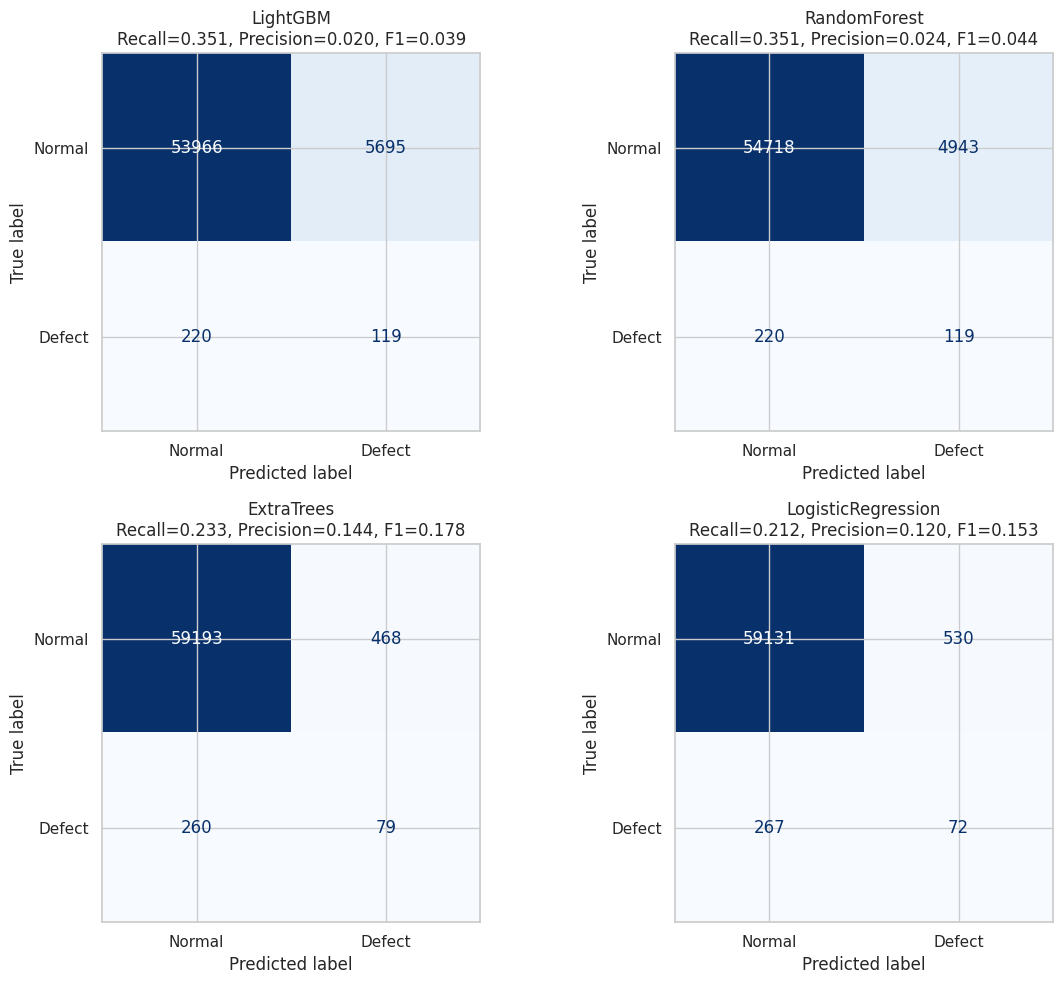

,model_name,accuracy,false_positive_rate,precision,recall,f1,roc_auc,pr_auc,threshold
0,RandomForest,0.913950,0.082851,0.023508,0.351032,0.044066,0.696746,0.062551,0.058868
1,ExtraTrees,0.987867,0.007844,0.144424,0.233038,0.178330,0.676183,0.057577,0.243180
2,LogisticRegression,0.986717,0.008884,0.119601,0.212389,0.153029,0.662734,0.050958,0.898330
3,LightGBM,0.901417,0.095456,0.020468,0.351032,0.038680,0.665979,0.050323,0.034547


In [19]:
print("== Selected Model ==")
print("model:", selected_model_name)
print("best_threshold:", round(best_threshold, 5))
print(classification_report(y_valid, valid_pred, digits=4, zero_division=0))

# 후보 모델별 Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, (model_name, cm_model) in zip(axes, model_confusion_matrices.items()):
    ConfusionMatrixDisplay(cm_model, display_labels=["Normal", "Defect"]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )
    row = model_comparison[model_comparison["model_name"].eq(model_name)].iloc[0]
    ax.set_title(
        f"{model_name}\n"
        f"Recall={row['recall']:.3f}, Precision={row['precision']:.3f}, F1={row['f1']:.3f}"
    )
plt.tight_layout()
plt.show()

# 비교 지표 테이블
display(model_comparison[[
    "model_name",
    "accuracy",
    "false_positive_rate",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "threshold",
]])


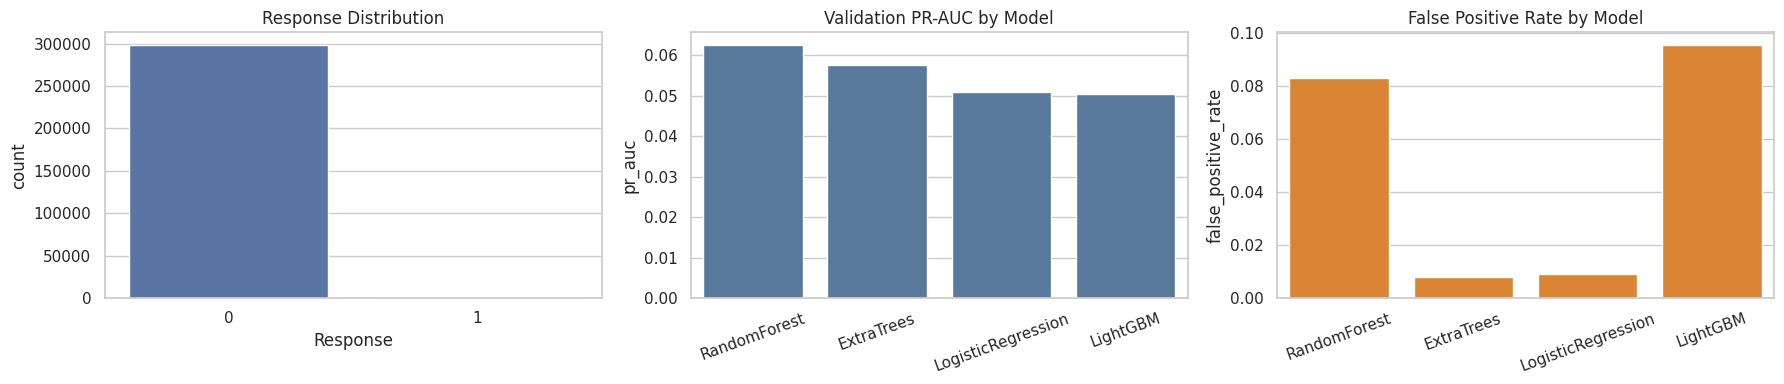

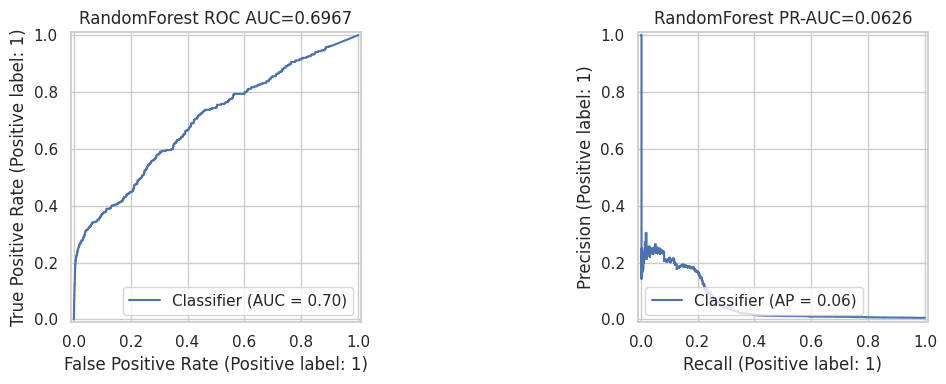

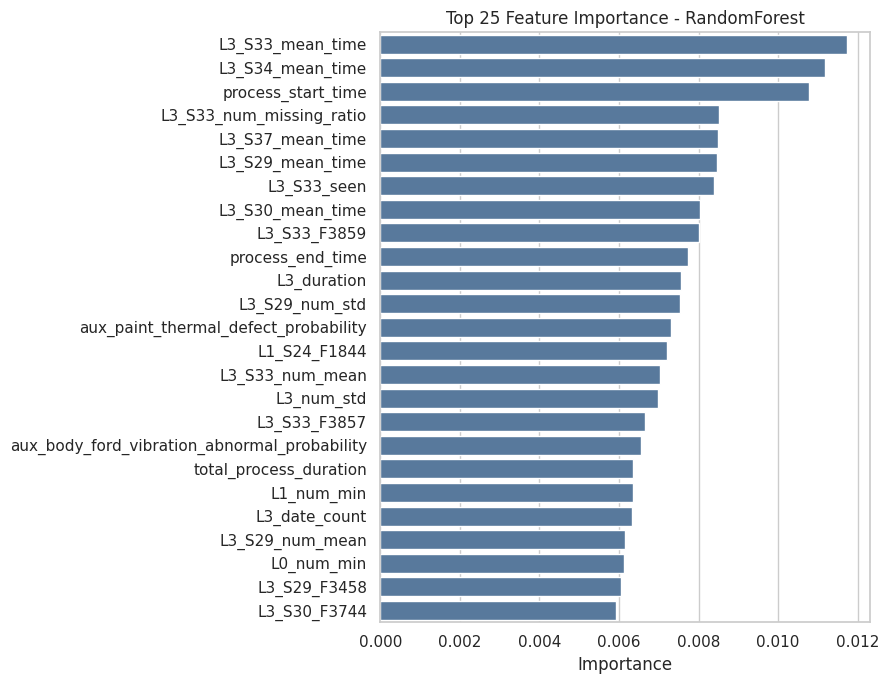

,model_name,feature,importance_gain,importance_type
457,RandomForest,L3_S33_mean_time,0.011733,feature_importances
458,RandomForest,L3_S34_mean_time,0.011186,feature_importances
459,RandomForest,process_start_time,0.010766,feature_importances
460,RandomForest,L3_S33_num_missing_ratio,0.008505,feature_importances
461,RandomForest,L3_S37_mean_time,0.008500,feature_importances
462,RandomForest,L3_S29_mean_time,0.008475,feature_importances
463,RandomForest,L3_S33_seen,0.008394,feature_importances
464,RandomForest,L3_S30_mean_time,0.008029,feature_importances
465,RandomForest,L3_S33_F3859,0.008004,feature_importances
466,RandomForest,process_end_time,0.007741,feature_importances


In [20]:
# 모델 성능 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x=y, ax=axes[0])
axes[0].set_title("Response Distribution")
axes[0].set_xlabel("Response")

sns.barplot(data=model_comparison, x="model_name", y="pr_auc", ax=axes[1], color="#4C78A8")
axes[1].set_title("Validation PR-AUC by Model")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=model_comparison, x="model_name", y="false_positive_rate", ax=axes[2], color="#F58518")
axes[2].set_title("False Positive Rate by Model")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# 선택 모델 ROC/PR 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_valid, valid_proba, ax=axes[0])
axes[0].set_title(f"{selected_model_name} ROC AUC={roc_auc:.4f}")
PrecisionRecallDisplay.from_predictions(y_valid, valid_proba, ax=axes[1])
axes[1].set_title(f"{selected_model_name} PR-AUC={pr_auc:.4f}")
plt.tight_layout()
plt.show()


def extract_feature_importance(estimator, feature_names: list[str], model_name: str) -> pd.DataFrame:
    target_estimator = estimator
    if is_pipeline_estimator(estimator):
        target_estimator = get_final_estimator(estimator)

    if hasattr(target_estimator, "booster_"):
        values = target_estimator.booster_.feature_importance(importance_type="gain")
        importance_type = "gain"
    elif hasattr(target_estimator, "feature_importances_"):
        values = target_estimator.feature_importances_
        importance_type = "feature_importances"
    elif hasattr(target_estimator, "coef_"):
        values = np.abs(target_estimator.coef_).ravel()
        importance_type = "abs_coef"
    else:
        values = np.zeros(len(feature_names))
        importance_type = "not_available"

    return pd.DataFrame({
        "model_name": model_name,
        "feature": feature_names,
        "importance": values,
        "importance_type": importance_type,
    }).sort_values("importance", ascending=False)


importance_frames = [
    extract_feature_importance(estimator, feature_cols, model_name)
    for model_name, estimator in trained_models.items()
]
all_model_importance = pd.concat(importance_frames, ignore_index=True)
importance_df = all_model_importance[all_model_importance["model_name"].eq(selected_model_name)].copy()
importance_df = importance_df.rename(columns={"importance": "importance_gain"})

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(25), y="feature", x="importance_gain", color="#4C78A8")
plt.title(f"Top 25 Feature Importance - {selected_model_name}")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(importance_df.head(30))


## 10. SHAP 기반 영향 공정 분석

선택된 최종 모델을 기준으로 SHAP 값을 계산합니다.

SHAP 값은 feature가 불량 확률 예측에 기여한 정도이며, 이후 feature를 공정 코드로 매핑해 공정별 영향도를 집계합니다.


In [22]:
# SHAP 샘플링
SHAP_SAMPLE_SIZE = min(1000, len(X_valid))

if selected_model_name == "LogisticRegression":
    SHAP_SAMPLE_SIZE = min(500, len(X_valid))

X_shap = X_valid.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
id_shap = id_valid.loc[X_shap.index]
y_shap = y_valid.loc[X_shap.index]
proba_shap = predict_positive_proba(model, X_shap)


def prepare_shap_model(estimator, X_sample: pd.DataFrame):
    if is_pipeline_estimator(estimator):
        final_estimator = get_final_estimator(estimator)
        transform_steps = estimator.steps[:-1]

        X_transformed = X_sample.copy()

        for _, step in transform_steps:
            if hasattr(step, "transform"):
                X_transformed = step.transform(X_transformed)

        X_transformed = pd.DataFrame(
            X_transformed,
            columns=X_sample.columns,
            index=X_sample.index
        )

        return final_estimator, X_transformed

    return estimator, X_sample


shap_model, X_shap_model = prepare_shap_model(model, X_shap)

# SHAP Explainer 생성
try:
    explainer = shap.TreeExplainer(shap_model)

    raw_shap_values = explainer.shap_values(
        X_shap_model,
        check_additivity=False
    )

    if isinstance(raw_shap_values, list):
        shap_matrix = raw_shap_values[1]
    elif getattr(raw_shap_values, "ndim", 0) == 3:
        shap_matrix = raw_shap_values[:, :, 1]
    else:
        shap_matrix = raw_shap_values

    expected_value = explainer.expected_value

    if isinstance(expected_value, list):
        base_value = expected_value[1]
    else:
        base_value = expected_value

except Exception as e:
    print("TreeExplainer 실패:", e)
    print("Permutation Explainer로 대체 실행합니다.")

    background = shap.sample(
        X_train,
        min(100, len(X_train)),
        random_state=RANDOM_STATE
    )

    explainer = shap.Explainer(
        lambda data: predict_positive_proba(
            model,
            pd.DataFrame(data, columns=X_train.columns)
        ),
        background
    )

    raw_explanation = explainer(
        X_shap,
        max_evals=2 * X_shap.shape[1] + 1
    )

    shap_matrix = raw_explanation.values
    base_value = raw_explanation.base_values
    X_shap_model = X_shap


# base_value 길이 보정
if np.isscalar(base_value):
    base_values = np.repeat(base_value, len(X_shap))
else:
    base_values = np.array(base_value)

    if base_values.ndim == 0:
        base_values = np.repeat(float(base_values), len(X_shap))
    elif len(base_values) != len(X_shap):
        base_values = np.repeat(float(np.ravel(base_values)[0]), len(X_shap))


# SHAP 객체 구성
shap_values = shap.Explanation(
    values=shap_matrix,
    base_values=base_values,
    data=X_shap.values,
    feature_names=X_shap.columns.tolist(),
)


print("selected_model_name:", selected_model_name)
print("X_shap:", X_shap.shape)
print("X_shap_model:", X_shap_model.shape)
print("shap_matrix:", shap_matrix.shape)
print("base_values:", np.array(base_values).shape)

selected_model_name: RandomForest
X_shap: (1000, 457)
X_shap_model: (1000, 457)
shap_matrix: (1000, 457)
base_values: (1000,)


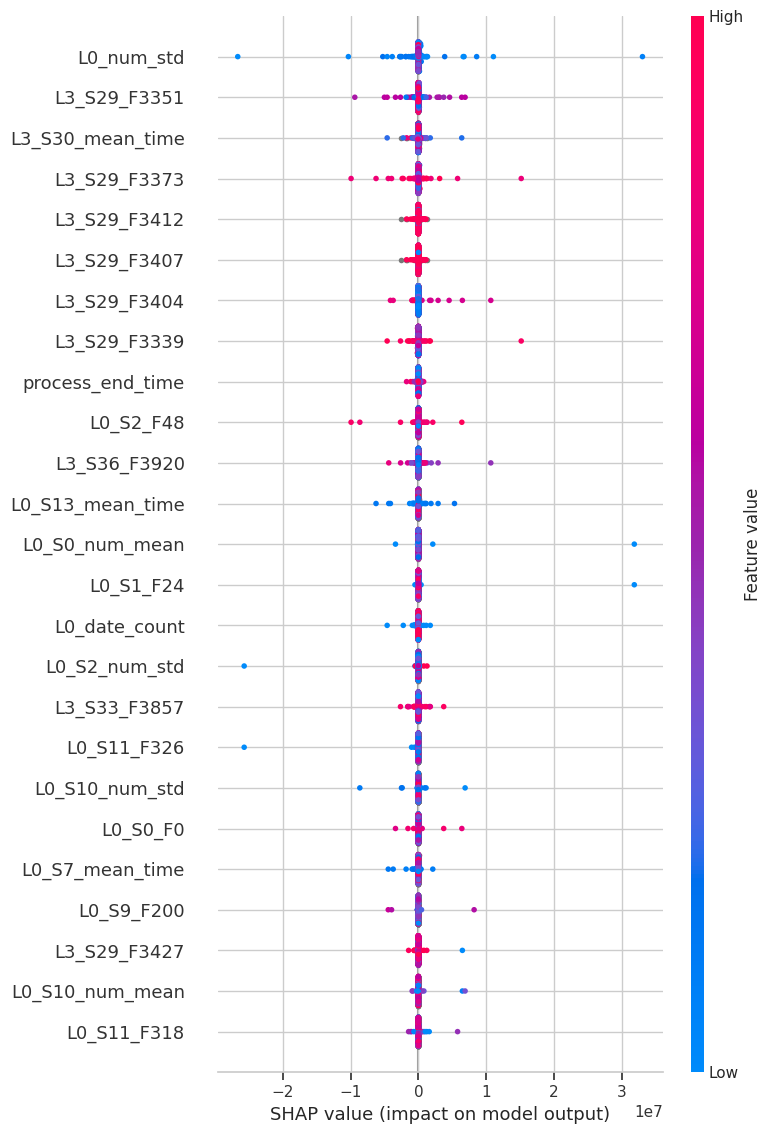

,feature,mean_abs_shap
341,L0_num_std,161153.464733
128,L3_S29_F3351,112466.467404
320,L3_S30_mean_time,87206.632845
134,L3_S29_F3373,79514.635807
145,L3_S29_F3412,67172.086809
144,L3_S29_F3407,50584.084076
143,L3_S29_F3404,47588.744257
124,L3_S29_F3339,45584.471179
263,process_end_time,41293.258694
16,L0_S2_F48,41259.724076


In [23]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_shap, max_display=25, show=True)

# SHAP 중요도 산출
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(30))


공정 영향도 집계 제외 전역/미매핑 feature 수: 9


,unmapped_feature
0,date_observed_count
1,date_missing_ratio
2,process_start_time
3,process_end_time
4,total_process_duration
5,max_station_span
6,mean_station_span
7,std_station_span
8,active_station_count


,process_code,mean_abs_shap,feature_count
0,PRESS,3987.411446,182
2,PAINT,3959.570471,197
3,ASSEMBLY,398.922157,36
1,BODY,71.636713,33


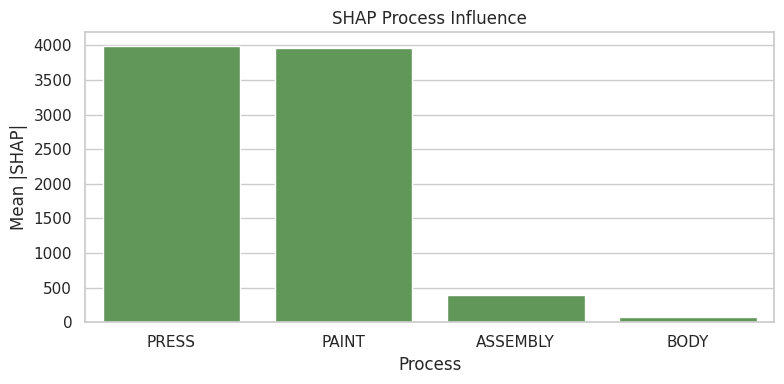

In [24]:
# Feature 공정 매핑
def feature_to_process(feature: str) -> str | None:
    """Feature 공정 매핑"""
    normalized = feature.lower()

    # Bosch 원천 컬럼/집계 컬럼: L0~L3 prefix 기준 매핑
    line = get_line(feature)
    if line in LINE_TO_PROCESS:
        return LINE_TO_PROCESS[line]

    # 보조 데이터셋 기반 feature: aux_{process}_... naming 기준 매핑
    if normalized.startswith("aux_press") or "press" in normalized:
        return "PRESS"
    if normalized.startswith("aux_body") or "body" in normalized or "robot" in normalized or "ford" in normalized:
        return "BODY"
    if normalized.startswith("aux_paint") or "paint" in normalized or "thermal" in normalized:
        return "PAINT"
    if normalized.startswith("aux_assembly") or "assembly" in normalized:
        return "ASSEMBLY"

    # 전역 feature 제외
    return None

# 후속 공정 매핑
def next_process(process_code: str) -> str:
    if process_code not in PROCESS_FLOW:
        return "FINAL_INSPECTION"
    idx = PROCESS_FLOW.index(process_code)
    if idx + 1 >= len(PROCESS_FLOW):
        return "FINAL_INSPECTION"
    return PROCESS_FLOW[idx + 1]

# 위험 등급 변환
def probability_to_risk_grade(prob: float) -> str:
    if prob >= 0.70:
        return "HIGH"
    if prob >= 0.40:
        return "MEDIUM"
    return "LOW"

# SHAP feature 공정 매핑
feature_process = pd.Series([feature_to_process(c) for c in X_shap.columns], index=X_shap.columns)
mapped_feature_mask = feature_process.isin(PROCESS_FLOW)
unmapped_features = feature_process[~mapped_feature_mask].index.tolist()
print(f"공정 영향도 집계 제외 전역/미매핑 feature 수: {len(unmapped_features)}")
if unmapped_features:
    display(pd.DataFrame({"unmapped_feature": unmapped_features}).head(30))

# 공정별 SHAP 영향도 집계
process_rows = []
for process_code in PROCESS_FLOW:
    cols_idx = np.where(feature_process.values == process_code)[0]
    process_rows.append({
        "process_code": process_code,
        "mean_abs_shap": float(np.abs(shap_matrix[:, cols_idx]).mean()) if len(cols_idx) else 0.0,
        "feature_count": int(len(cols_idx)),
    })

process_importance = pd.DataFrame(process_rows).sort_values("mean_abs_shap", ascending=False)
display(process_importance)

# 공정 영향도 시각화
plt.figure(figsize=(8, 4))
sns.barplot(data=process_importance, x="process_code", y="mean_abs_shap", color="#59A14F")
plt.title("SHAP Process Influence")
plt.xlabel("Process")
plt.ylabel("Mean |SHAP|")
plt.tight_layout()
plt.show()


## 11. SHAP 기반 전이 위험 결과 생성

아래 결과는 PRD의 `defect_transfer_prediction_result` 저장 구조에 맞춘 예측 테이블입니다.


In [25]:
# 전이 위험 결과 생성
def build_transfer_predictions(
    ids: pd.Series,
    probabilities: np.ndarray,
    shap_matrix: np.ndarray,
    feature_names: list[str],
    feature_process: pd.Series,
) -> pd.DataFrame:
    records = []
    process_values = feature_process.values
    predicted_at = datetime.now(timezone.utc).isoformat()

    # 샘플별 공정 영향도 계산
    for row_idx, (sample_id, prob) in enumerate(zip(ids.to_numpy(), probabilities)):
        abs_values = np.abs(shap_matrix[row_idx])
        mapped_mask = feature_process.isin(PROCESS_FLOW).to_numpy()
        mapped_abs_values = abs_values[mapped_mask]
        mapped_process_values = process_values[mapped_mask]
        total_abs = float(mapped_abs_values.sum()) or 1.0

        # 공정별 영향 비율
        process_scores = {}
        for process_code in PROCESS_FLOW:
            col_idx = np.where(mapped_process_values == process_code)[0]
            process_scores[process_code] = float(mapped_abs_values[col_idx].sum() / total_abs) if len(col_idx) else 0.0

        # 원인/대상 공정 산출
        source_process = max(process_scores, key=process_scores.get)
        target_process = next_process(source_process)
        source_col_idx = np.where(process_values == source_process)[0]
        top_feature_idx = int(source_col_idx[np.argmax(abs_values[source_col_idx])]) if len(source_col_idx) else int(abs_values.argmax())
        influence_score = process_scores[source_process]

        records.append({
            "car_master_id": int(sample_id),
            "source_process_code": source_process,
            "target_process_code": target_process,
            "current_defect_probability": round(float(influence_score), 6),
            "target_defect_probability": round(float(prob), 6),
            "predicted_defect_process": target_process,
            "risk_grade": probability_to_risk_grade(float(prob)),
            "main_cause": feature_names[top_feature_idx],
            "influence_score": round(float(influence_score), 6),
            "predicted_at": predicted_at,
        })
    return pd.DataFrame(records).sort_values(["target_defect_probability", "influence_score"], ascending=False)

# 전이 예측 테이블 생성
transfer_predictions = build_transfer_predictions(
    id_shap,
    proba_shap,
    shap_matrix,
    X_shap.columns.tolist(),
    feature_process,
)

display(transfer_predictions.head(30))

# 전이 위험 요약
risk_summary = transfer_predictions.groupby(["source_process_code", "target_process_code", "risk_grade"]).agg(
    vehicle_count=("car_master_id", "count"),
    avg_target_defect_probability=("target_defect_probability", "mean"),
    avg_influence_score=("influence_score", "mean"),
).reset_index().sort_values(["avg_target_defect_probability", "vehicle_count"], ascending=False)
display(risk_summary)


,car_master_id,source_process_code,target_process_code,current_defect_probability,target_defect_probability,predicted_defect_process,risk_grade,main_cause,influence_score,predicted_at
883,49121,PAINT,ASSEMBLY,0.563811,0.619726,ASSEMBLY,MEDIUM,L3_S30_mean_time,0.563811,2026-06-18T05:32:50.034461+00:00
179,84100,PAINT,ASSEMBLY,0.747158,0.618208,ASSEMBLY,MEDIUM,L3_S36_F3920,0.747158,2026-06-18T05:32:50.034461+00:00
76,495820,PAINT,ASSEMBLY,0.787374,0.342941,ASSEMBLY,LOW,L3_S29_F3407,0.787374,2026-06-18T05:32:50.034461+00:00
65,46831,PAINT,ASSEMBLY,0.788540,0.257915,ASSEMBLY,LOW,L3_S30_mean_time,0.788540,2026-06-18T05:32:50.034461+00:00
447,533156,PAINT,ASSEMBLY,0.787341,0.230440,ASSEMBLY,LOW,L3_S29_F3407,0.787341,2026-06-18T05:32:50.034461+00:00
543,199536,PAINT,ASSEMBLY,0.592871,0.198408,ASSEMBLY,LOW,L3_S29_F3449,0.592871,2026-06-18T05:32:50.034461+00:00
695,86810,PAINT,ASSEMBLY,0.842617,0.186797,ASSEMBLY,LOW,L3_S30_mean_time,0.842617,2026-06-18T05:32:50.034461+00:00
132,457589,PAINT,ASSEMBLY,0.653267,0.184589,ASSEMBLY,LOW,L3_S30_mean_time,0.653267,2026-06-18T05:32:50.034461+00:00
88,361134,PAINT,ASSEMBLY,0.500231,0.183003,ASSEMBLY,LOW,L3_S30_F3504,0.500231,2026-06-18T05:32:50.034461+00:00
532,293981,PAINT,ASSEMBLY,0.784869,0.166225,ASSEMBLY,LOW,L3_S29_F3407,0.784869,2026-06-18T05:32:50.034461+00:00


,source_process_code,target_process_code,risk_grade,vehicle_count,avg_target_defect_probability,avg_influence_score
2,PAINT,ASSEMBLY,MEDIUM,2,0.618967,0.655485
0,ASSEMBLY,FINAL_INSPECTION,LOW,1,0.047076,0.495199
3,PRESS,BODY,LOW,117,0.030476,0.588225
1,PAINT,ASSEMBLY,LOW,880,0.026473,0.719373


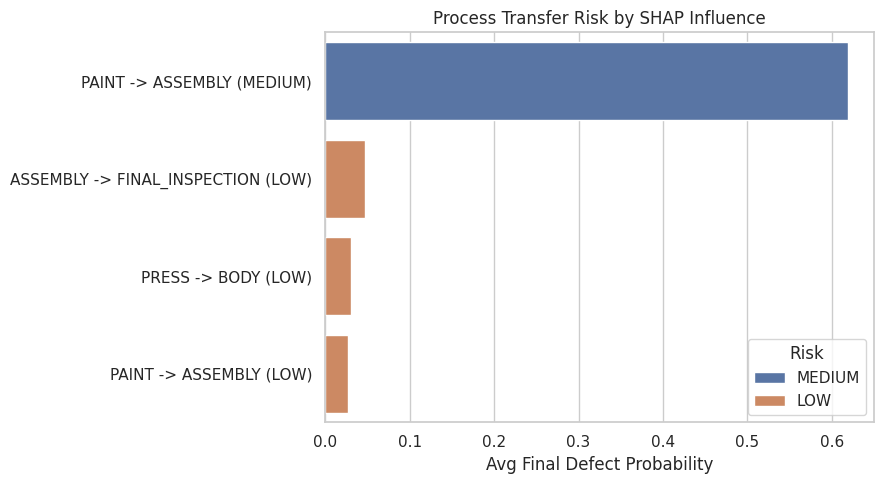

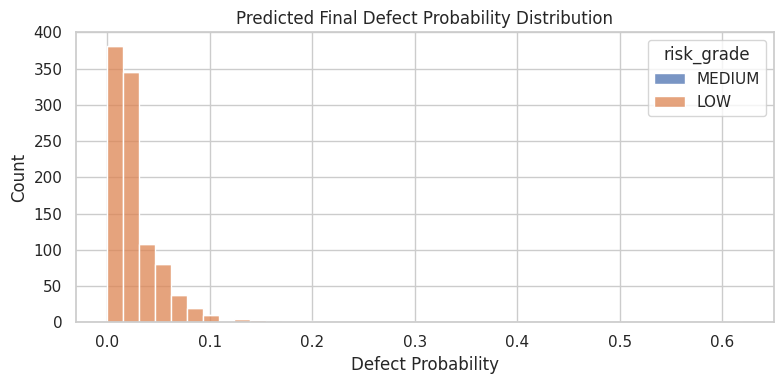

In [26]:
# 전이 위험 시각화
plt.figure(figsize=(9, 5))
top_flow = risk_summary.head(12).copy()
top_flow["flow"] = top_flow["source_process_code"] + " -> " + top_flow["target_process_code"] + " (" + top_flow["risk_grade"] + ")"
sns.barplot(data=top_flow, y="flow", x="avg_target_defect_probability", hue="risk_grade", dodge=False)
plt.title("Process Transfer Risk by SHAP Influence")
plt.xlabel("Avg Final Defect Probability")
plt.ylabel("")
plt.legend(title="Risk")
plt.tight_layout()
plt.show()

# 불량 확률 분포 시각화
plt.figure(figsize=(8, 4))
sns.histplot(data=transfer_predictions, x="target_defect_probability", hue="risk_grade", bins=40, multiple="stack")
plt.title("Predicted Final Defect Probability Distribution")
plt.xlabel("Defect Probability")
plt.tight_layout()
plt.show()


## 12. AI 모델 관리 항목

모델 선정 근거, 데이터셋 규모, 테스트 케이스 수, Accuracy, False Positive Rate, 성능 개선 현황을 운영 관리용 요약으로 정리합니다.


In [27]:
ai_management_table = pd.DataFrame([
    {"관리 항목": "모델 선정 근거 정리", "값": ai_management_summary["모델_선정_근거"]},
    {"관리 항목": "데이터셋 규모 관리", "값": json.dumps(ai_management_summary["데이터셋_규모_관리"], ensure_ascii=False)},
    {"관리 항목": "테스트 케이스 수 관리", "값": json.dumps(ai_management_summary["테스트_케이스_수_관리"], ensure_ascii=False)},
    {"관리 항목": "정확도(Accuracy) 측정", "값": round(ai_management_summary["정확도_Accuracy"], 6)},
    {"관리 항목": "오탐률(False Positive Rate) 측정", "값": round(ai_management_summary["오탐률_False_Positive_Rate"], 6)},
    {"관리 항목": "모델 성능 개선 현황 관리", "값": json.dumps(ai_management_summary["모델_성능_개선_현황"], ensure_ascii=False)},
])

display(ai_management_table)


,관리 항목,값
0,모델 선정 근거 정리,RandomForest 모델이 validation PR-AUC/Recall/F1 기...
1,데이터셋 규모 관리,"{""max_rows"": 300000, ""profile_rows"": 50000, ""t..."
2,테스트 케이스 수 관리,"{""validation_total"": 60000, ""validation_normal..."
3,정확도(Accuracy) 측정,0.91395
4,오탐률(False Positive Rate) 측정,0.082851
5,모델 성능 개선 현황 관리,"{""baseline_model"": ""LightGBM"", ""baseline_pr_au..."


## 13. 모델 및 결과 저장


In [28]:
# 저장 경로
selected_model_path = OUTPUT_DIR / "selected_defect_detector.joblib"
selected_model_pkl_path = OUTPUT_DIR / "selected_defect_detector.pkl"
candidate_models_path = OUTPUT_DIR / "candidate_defect_models.joblib"
candidate_models_pkl_path = OUTPUT_DIR / "candidate_defect_models.pkl"
model_path = OUTPUT_DIR / "lightgbm_defect_detector.joblib"
model_pkl_path = OUTPUT_DIR / "lightgbm_defect_detector.pkl"
aux_model_path = OUTPUT_DIR / "auxiliary_process_models.joblib"
aux_model_pkl_path = OUTPUT_DIR / "auxiliary_process_models.pkl"
feature_path = OUTPUT_DIR / "defect_model_features.json"
metrics_path = OUTPUT_DIR / "defect_model_metrics.json"
comparison_path = OUTPUT_DIR / "defect_model_comparison.csv"
confusion_matrix_path = OUTPUT_DIR / "defect_model_confusion_matrices.json"
ai_management_path = OUTPUT_DIR / "defect_ai_management_summary.json"
importance_path = OUTPUT_DIR / "defect_model_feature_importance.csv"
all_importance_path = OUTPUT_DIR / "defect_all_model_feature_importance.csv"
shap_importance_path = OUTPUT_DIR / "defect_shap_importance.csv"
transfer_path = OUTPUT_DIR / "defect_transfer_prediction_result.csv"
risk_summary_path = OUTPUT_DIR / "defect_transfer_risk_summary.csv"

# 모델 저장
joblib.dump(model, selected_model_path)
joblib.dump(trained_models, candidate_models_path)
joblib.dump(auxiliary_models, aux_model_path)
with open(selected_model_pkl_path, "wb") as f:
    pickle.dump(model, f)
with open(candidate_models_pkl_path, "wb") as f:
    pickle.dump(trained_models, f)
with open(aux_model_pkl_path, "wb") as f:
    pickle.dump(auxiliary_models, f)

# 기존 LightGBM 파일명 호환 저장
if "LightGBM" in trained_models:
    joblib.dump(trained_models["LightGBM"], model_path)
    with open(model_pkl_path, "wb") as f:
        pickle.dump(trained_models["LightGBM"], f)

feature_path.write_text(json.dumps(feature_cols, ensure_ascii=False, indent=2), encoding="utf-8")

confusion_payload = {
    name: matrix.tolist()
    for name, matrix in model_confusion_matrices.items()
}
confusion_matrix_path.write_text(json.dumps(confusion_payload, ensure_ascii=False, indent=2), encoding="utf-8")
ai_management_path.write_text(json.dumps(ai_management_summary, ensure_ascii=False, indent=2), encoding="utf-8")

# 평가 지표 저장
metrics = {
    "selected_model_name": selected_model_name,
    "roc_auc": float(roc_auc),
    "average_precision": float(pr_auc),
    "accuracy": float(accuracy),
    "false_positive_rate": float(false_positive_rate),
    "best_threshold": float(best_threshold),
    "f1_at_best_threshold": float(f1_score(y_valid, valid_pred, zero_division=0)),
    "confusion_matrix": cm.tolist(),
    "train_rows": int(len(X_train)),
    "valid_rows": int(len(X_valid)),
    "feature_count": int(len(feature_cols)),
    "positive_ratio_train": float(y_train.mean()),
    "candidate_models": list(trained_models.keys()),
    "cv_splits": int(effective_cv_splits),
    "cv_trials_per_model": int(CV_N_ITER if ENABLE_HYPERPARAMETER_TUNING else 1),
    "lightgbm_tuning_method": "Optuna" if ENABLE_OPTUNA_TUNING else "ParameterSampler",
    "smote_enabled": bool(USE_SMOTE),
    "smote_sampling_strategy": float(SMOTE_SAMPLING_STRATEGY),
    "threshold_strategy": {
        "type": "recall_priority",
        "target_recall": float(RECALL_PRIORITY_TARGET),
        "min_precision": float(RECALL_PRIORITY_MIN_PRECISION),
        "beta": float(THRESHOLD_BETA),
    },
    "model_selection_reason": ai_management_summary["모델_선정_근거"],
    "auxiliary_metrics": auxiliary_metrics,
    "auxiliary_feature_columns": [c for c in feature_cols if c.startswith("aux_")],
    "created_at": datetime.now(timezone.utc).isoformat(),
}
metrics_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")

# 분석 결과 저장
cv_results.to_csv(cv_results_path, index=False)
if "cv_fold_results" in globals():
    cv_fold_results.to_csv(cv_fold_results_path, index=False)
model_comparison.to_csv(comparison_path, index=False)
importance_df.to_csv(importance_path, index=False)
all_model_importance.to_csv(all_importance_path, index=False)
shap_importance.to_csv(shap_importance_path, index=False)
transfer_predictions.to_csv(transfer_path, index=False)
risk_summary.to_csv(risk_summary_path, index=False)

print("Saved outputs:")
for path in [
    selected_model_path,
    selected_model_pkl_path,
    candidate_models_path,
    candidate_models_pkl_path,
    model_path,
    model_pkl_path,
    aux_model_path,
    aux_model_pkl_path,
    feature_path,
    metrics_path,
    cv_results_path,
    comparison_path,
    confusion_matrix_path,
    ai_management_path,
    importance_path,
    all_importance_path,
    shap_importance_path,
    transfer_path,
    risk_summary_path,
]:
    print(path)


Saved outputs:
/content/defect_transfer_outputs/selected_defect_detector.joblib
/content/defect_transfer_outputs/selected_defect_detector.pkl
/content/defect_transfer_outputs/candidate_defect_models.joblib
/content/defect_transfer_outputs/candidate_defect_models.pkl
/content/defect_transfer_outputs/lightgbm_defect_detector.joblib
/content/defect_transfer_outputs/lightgbm_defect_detector.pkl
/content/defect_transfer_outputs/auxiliary_process_models.joblib
/content/defect_transfer_outputs/auxiliary_process_models.pkl
/content/defect_transfer_outputs/defect_model_features.json
/content/defect_transfer_outputs/defect_model_metrics.json
/content/defect_transfer_outputs/defect_model_cv_results.csv
/content/defect_transfer_outputs/defect_model_comparison.csv
/content/defect_transfer_outputs/defect_model_confusion_matrices.json
/content/defect_transfer_outputs/defect_ai_management_summary.json
/content/defect_transfer_outputs/defect_model_feature_importance.csv
/content/defect_transfer_outputs